# Lighthouse Sanctuary — Full Exploratory Data Analysis (CSV v7)

**This file is the EDA:** run the markdown and code cells below in Jupyter (no separate Python script).

**Audience:** data science and program leadership. **Environment:** Python 3.11+.

Open this notebook from the project root (or `notebooks/`), then **Run All** after `pip install -r requirements.txt`.

---

## Business lens: INTEX case (why this EDA matters)

The **INTEX** scenario is a *new* organization modeled on **Lighthouse Sanctuary**: safe homes and rehabilitation for girls who are survivors of abuse and trafficking, funded almost entirely by **donations**, with **limited staff** and **no dedicated marketing team**. Lighthouse shared **anonymized** operational data so the client can learn what to **collect** and **measure** before launch.

We interpret every finding below against the client’s stated goals:

| Case theme | What the client needs from data |
|------------|----------------------------------|
| **Donor & support** | Retention and growth; which campaigns and channels move the needle; who might give more or **lapse**; **personalized** outreach; **linking gifts to resident outcomes** for donor communications (impact story). |
| **Case management** | Who is **progressing vs struggling**; which **interventions** appear associated with movement; readiness for **reintegration** vs **regression** risk; nothing “falling through the cracks” across safehouses. |
| **Outreach & social** | What to post, where, when, and which content relates to **donations**—not only likes—and how to decide without a full marketing team. |
| **Privacy & trust** | All reporting here uses **sample / anonymized** Lighthouse-style data; production systems must protect minors and survivors; aggregated **impact** views for donors, strict access for identifiable case data. |

The **17 CSV tables** map to the case’s three domains: **Donor & Support**, **Case Management**, and **Outreach & Communication**. When we summarize correlations or trends, we tie them back to these decisions—not abstract statistics alone.



In [38]:
# --- Setup ---
import ast
import json as pyjson
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import skew

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths: notebook may run from repo root or notebooks/
for _base in [Path.cwd(), Path.cwd().parent]:
    _d = _base / "lighthouse_csv_v7"
    if _d.is_dir():
        DATA_DIR = _d.resolve()
        break
else:
    DATA_DIR = (Path.cwd().parent / "lighthouse_csv_v7").resolve()

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

try:
    from IPython.display import display
except ImportError:
    display = print


def pairwise_corr_summary(df, cols, method="pearson", min_obs=15):
    """All unique pairs: correlation (Pearson or Spearman), two-sided p-value, n, strength label."""
    rows = []
    for i, a in enumerate(cols):
        for b in cols[i + 1 :]:
            sub = df[[a, b]].dropna()
            n = len(sub)
            if n < min_obs:
                continue
            if method == "pearson":
                coef, p = stats.pearsonr(sub[a], sub[b])
            else:
                coef, p = stats.spearmanr(sub[a], sub[b])
            ac = abs(coef)
            if ac < 0.10:
                tier = "negligible"
            elif ac < 0.30:
                tier = "weak"
            elif ac < 0.50:
                tier = "moderate"
            elif ac < 0.70:
                tier = "strong"
            else:
                tier = "very strong"
            rows.append(
                {
                    "var_a": a,
                    "var_b": b,
                    "n": n,
                    "coefficient": round(float(coef), 4),
                    "abs_coefficient": round(float(ac), 4),
                    "p_value": float(p),
                    "strength": tier,
                }
            )
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)


def numeric_by_category_summary(df, value_col, group_col, min_per_group=3):
    """Per-group counts and medians; Kruskal-Wallis p-value across groups."""
    sub = df[[value_col, group_col]].dropna()
    groups = [g[value_col].values for _, g in sub.groupby(group_col) if len(g) >= min_per_group]
    kw = None
    if len(groups) >= 2:
        h_stat, p = stats.kruskal(*groups)
        kw = {"H": float(h_stat), "p_value": float(p)}
    med = sub.groupby(group_col)[value_col].agg(["count", "median", "mean"]).sort_values("median", ascending=False)
    return med, kw


def crosstab_chi2_summary(ct: pd.DataFrame, title: str) -> None:
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, k = ct.shape
    cramers_v = float(np.sqrt(chi2 / (n * (min(r, k) - 1)))) if n > 0 and min(r, k) >= 2 else float("nan")
    print(f"\n{title}")
    print(f"  χ² = {chi2:.2f}, df = {dof}, p = {p:.4g}")
    print(f"  Cramér's V ≈ {cramers_v:.3f} (0 = no association, up to ~1 = strong for this table size)")
    if (exp < 5).any():
        print("  Note: some expected counts < 5; treat p-value as approximate.")


print("DATA_DIR:", DATA_DIR)



DATA_DIR: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA/lighthouse_csv_v7


## 1. Data understanding

We load **17 related tables** (Lighthouse safehouse operations, residents, donations, partners, social posts). Below: shapes, dtypes, heads, and inferred keys/relationships.



In [39]:
FILE_MAP = {
    "safehouses": "safehouses.csv",
    "residents": "residents.csv",
    "supporters": "supporters.csv",
    "donations": "donations.csv",
    "donation_allocations": "donation_allocations.csv",
    "in_kind_donation_items": "in_kind_donation_items.csv",
    "health_wellbeing_records": "health_wellbeing_records.csv",
    "education_records": "education_records.csv",
    "intervention_plans": "intervention_plans.csv",
    "incident_reports": "incident_reports.csv",
    "safehouse_monthly_metrics": "safehouse_monthly_metrics.csv",
    "home_visitations": "home_visitations.csv",
    "process_recordings": "process_recordings.csv",
    "partners": "partners.csv",
    "partner_assignments": "partner_assignments.csv",
    "public_impact_snapshots": "public_impact_snapshots.csv",
    "social_media_posts": "social_media_posts.csv",
}

raw = {name: pd.read_csv(DATA_DIR / fname) for name, fname in FILE_MAP.items()}

profile_rows = []
for name, df in raw.items():
    profile_rows.append(
        {
            "table": name,
            "rows": len(df),
            "cols": df.shape[1],
            "memory_mb": df.memory_usage(deep=True).sum() / 1e6,
        }
    )
profile = pd.DataFrame(profile_rows).sort_values("rows", ascending=False)
display(profile)

for name in sorted(raw.keys()):
    df = raw[name]
    print("\n" + "=" * 72)
    print(f"TABLE: {name}  |  shape={df.shape}")
    print("dtypes:\n", df.dtypes)
    display(df.head(3))



,table,rows,cols,memory_mb
12,process_recordings,2819,15,1.589044
11,home_visitations,1337,14,0.922885
16,social_media_posts,812,39,0.909100
6,health_wellbeing_records,534,14,0.109725
7,education_records,534,10,0.209036
4,donation_allocations,521,7,0.082106
10,safehouse_monthly_metrics,450,11,0.085632
3,donations,420,13,0.177773
8,intervention_plans,180,11,0.098297
5,in_kind_donation_items,129,9,0.039794



TABLE: donation_allocations  |  shape=(521, 7)
dtypes:
 allocation_id         int64
donation_id           int64
safehouse_id          int64
program_area         object
amount_allocated    float64
allocation_date      object
allocation_notes    float64
dtype: object


,allocation_id,donation_id,safehouse_id,program_area,amount_allocated,allocation_date,allocation_notes
0,1,1,2,Education,717.18,2025-12-31,NaN
1,2,2,4,Transport,35.15,2025-12-02,NaN
2,3,3,8,Wellbeing,1074.65,2024-12-02,NaN



TABLE: donations  |  shape=(420, 13)
dtypes:
 donation_id           int64
supporter_id          int64
donation_type        object
donation_date        object
is_recurring           bool
campaign_name        object
channel_source       object
currency_code        object
amount              float64
estimated_value     float64
impact_unit          object
notes                object
referral_post_id    float64
dtype: object


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.15,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.65,1074.65,pesos,Campaign support,NaN


...

,safehouse_id,safehouse_code,name,region,city,province,country,open_date,status,capacity_girls,capacity_staff,current_occupancy,notes
0,1,SH01,Lighthouse Safehouse 1,Luzon,Quezon City,Metro Manila,Philippines,2022-01-01,Active,8,4,8,NaN
1,2,SH02,Lighthouse Safehouse 2,Visayas,Cebu City,Cebu,Philippines,2022-02-15,Active,10,5,8,NaN
2,3,SH03,Lighthouse Safehouse 3,Mindanao,Davao City,Davao del Sur,Philippines,2022-04-01,Active,9,4,9,NaN



TABLE: social_media_posts  |  shape=(812, 39)
dtypes:
 post_id                           int64
platform                         object
platform_post_id                 object
post_url                         object
created_at                       object
day_of_week                      object
post_hour                         int64
post_type                        object
media_type                       object
caption                          object
hashtags                         object
num_hashtags                      int64
mentions_count                    int64
has_call_to_action                 bool
call_to_action_type              object
content_topic                    object
sentiment_tone                   object
caption_length                    int64
features_resident_story            bool
campaign_name                    object
is_boosted                         bool
boost_budget_php                float64
impressions                       int64
reach                   

,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN



TABLE: supporters  |  shape=(60, 15)
dtypes:
 supporter_id            int64
supporter_type         object
display_name           object
organization_name      object
first_name             object
last_name              object
relationship_type      object
region                 object
country                object
email                  object
phone                  object
status                 object
created_at             object
first_donation_date    object
acquisition_channel    object
dtype: object


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01 00:00:00,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06 00:00:00,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11 00:00:00,2023-06-25,SocialMedia


### 1.1 Inferred primary keys, foreign keys, and joins

| Entity | Primary key (inferred) | Foreign keys / links |
|--------|------------------------|----------------------|
| safehouses | `safehouse_id` | — |
| residents | `resident_id` | `safehouse_id` → safehouses |
| supporters | `supporter_id` | — |
| donations | `donation_id` | `supporter_id` → supporters; optional `referral_post_id` → social_media_posts |
| donation_allocations | `allocation_id` | `donation_id`, `safehouse_id` |
| in_kind_donation_items | `item_id` | `donation_id` |
| health / education / interventions / incidents / visitations / process_recordings | respective `*_id` | `resident_id` → residents (incidents also `safehouse_id`) |
| safehouse_monthly_metrics | `metric_id` | `safehouse_id` |
| partners | `partner_id` | — |
| partner_assignments | `assignment_id` | `partner_id`, `safehouse_id` |
| public_impact_snapshots | `snapshot_id` | aggregate only |
| social_media_posts | `post_id` | linked from donations |

**ERD (text):** `safehouses` 1—* `residents`; `supporters` 1—* `donations`; `donations` 1—* `donation_allocations` and `in_kind_donation_items`; `donations` *—0..1 `social_media_posts`; `residents` 1—* longitudinal child tables; `safehouses` 1—* `safehouse_monthly_metrics`, `incident_reports`, `partner_assignments`; `partners` 1—* `partner_assignments`.



## 2. Data cleaning

We quantify missingness and duplicates, standardize types (especially dates and IDs), parse the impact JSON column, derive numeric age/stay features from text where possible, and flag outliers (IQR) without dropping unless clearly invalid. Decisions are summarized after the code.



--- Duplicate PK check ---
safehouses duplicate safehouse_id: 0
residents duplicate resident_id: 0
supporters duplicate supporter_id: 0
donations duplicate donation_id: 0
donation_allocations duplicate allocation_id: 0
in_kind_donation_items duplicate item_id: 0
health_wellbeing_records duplicate health_record_id: 0
education_records duplicate education_record_id: 0
intervention_plans duplicate plan_id: 0
incident_reports duplicate incident_id: 0
safehouse_monthly_metrics duplicate metric_id: 0
home_visitations duplicate visitation_id: 0
process_recordings duplicate recording_id: 0
partners duplicate partner_id: 0
partner_assignments duplicate assignment_id: 0
public_impact_snapshots duplicate snapshot_id: 0
social_media_posts duplicate post_id: 0


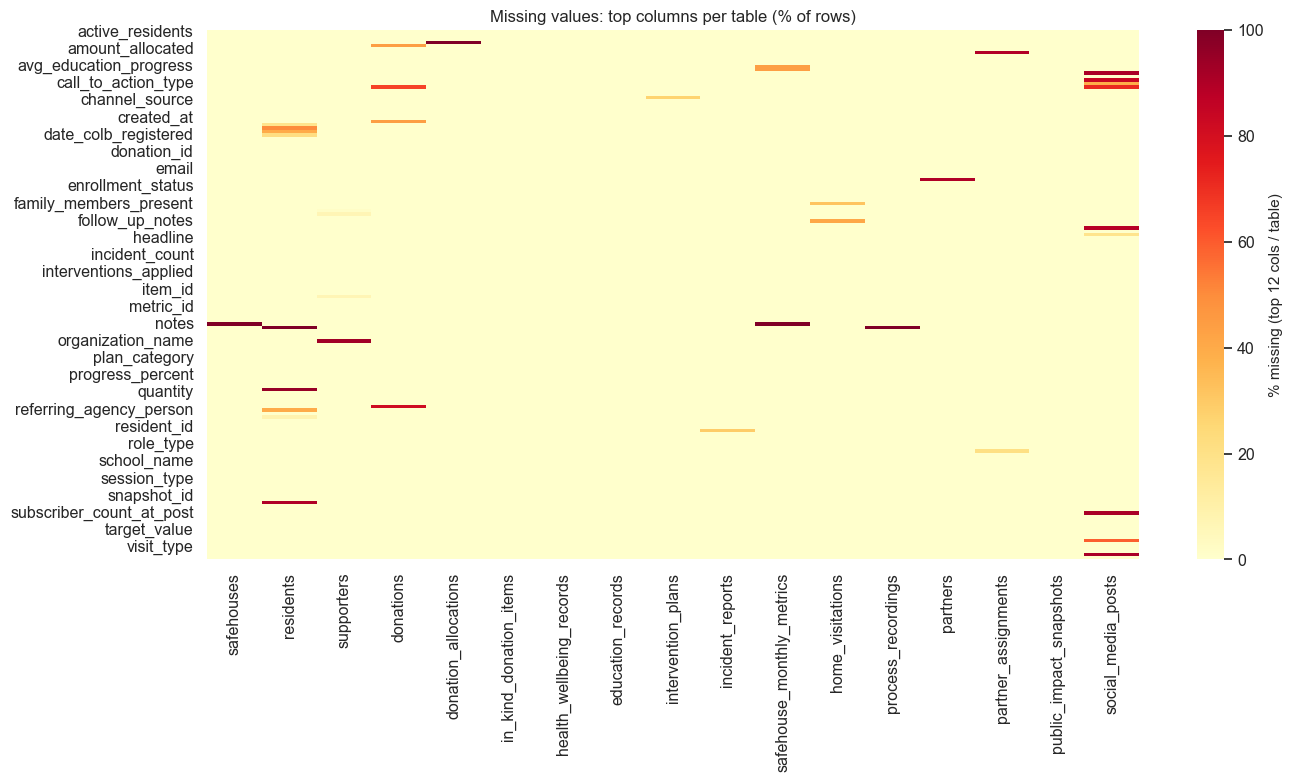

Residents with invalid safehouse_id: 0
Allocations orphan donation_id: 0
Allocations orphan safehouse_id: 0
Donations orphan supporter_id: 0
Donations with referral_post_id set: 77
Referrals not in posts table: 0
Monetary donation amount IQR outliers: 7 of 234
• Cast partner_assignments.safehouse_id to nullable Int64 after fixing float storage.
• Parsed datetime columns with errors='coerce'; invalid strings become NaT.
• Parsed public_impact_snapshots payloads via ast.literal_eval; expanded to payload_* columns.
• Derived present_age_years_est, length_of_stay_years_est, age_upon_admission_years_est from text.
• Added amount_php and est_value_num on donations; analyze monetary vs time separately.
• Outliers: flagged via IQR for reporting; no row deletion in this notebook.


In [40]:
def pk_dup_report(df: pd.DataFrame, pk: str, label: str) -> None:
    if pk not in df.columns:
        print(f"{label}: no column {pk}")
        return
    dup = df[pk].duplicated().sum()
    print(f"{label} duplicate {pk}: {dup}")


PKS = {
    "safehouses": "safehouse_id",
    "residents": "resident_id",
    "supporters": "supporter_id",
    "donations": "donation_id",
    "donation_allocations": "allocation_id",
    "in_kind_donation_items": "item_id",
    "health_wellbeing_records": "health_record_id",
    "education_records": "education_record_id",
    "intervention_plans": "plan_id",
    "incident_reports": "incident_id",
    "safehouse_monthly_metrics": "metric_id",
    "home_visitations": "visitation_id",
    "process_recordings": "recording_id",
    "partners": "partner_id",
    "partner_assignments": "assignment_id",
    "public_impact_snapshots": "snapshot_id",
    "social_media_posts": "post_id",
}

print("--- Duplicate PK check ---")
for t, pk in PKS.items():
    pk_dup_report(raw[t], pk, t)

# Missingness heatmap data
miss_pct = {}
for name, df in raw.items():
    miss_pct[name] = (df.isna().mean() * 100).sort_values(ascending=False).head(12)
miss_df = pd.DataFrame(miss_pct).fillna(0)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(miss_df, ax=ax, cmap="YlOrRd", cbar_kws={"label": "% missing (top 12 cols / table)"})
ax.set_title("Missing values: top columns per table (% of rows)")
plt.tight_layout()
plt.show()

# Working copies
dfs = {k: v.copy() for k, v in raw.items()}

# partner_assignments: float safehouse_id → Int64
dfs["partner_assignments"]["safehouse_id"] = pd.to_numeric(
    dfs["partner_assignments"]["safehouse_id"], errors="coerce"
).astype("Int64")

# Parse dates (best-effort)
DATE_COLS = {
    "safehouses": ["open_date"],
    "residents": ["date_of_birth", "date_of_admission", "date_closed", "created_at", "date_colb_registered", "date_colb_obtained", "date_case_study_prepared", "date_enrolled"],
    "supporters": ["created_at", "first_donation_date"],
    "donations": ["donation_date"],
    "donation_allocations": ["allocation_date"],
    "health_wellbeing_records": ["record_date"],
    "education_records": ["record_date"],
    "intervention_plans": ["target_date", "case_conference_date", "created_at", "updated_at"],
    "incident_reports": ["incident_date", "resolution_date"],
    "safehouse_monthly_metrics": ["month_start", "month_end"],
    "home_visitations": ["visit_date"],
    "process_recordings": ["session_date"],
    "partners": ["start_date", "end_date"],
    "partner_assignments": ["assignment_start", "assignment_end"],
    "public_impact_snapshots": ["snapshot_date", "published_at"],
    "social_media_posts": ["created_at"],
}

for tbl, cols in DATE_COLS.items():
    for c in cols:
        if c in dfs[tbl].columns:
            dfs[tbl][c] = pd.to_datetime(dfs[tbl][c], errors="coerce")

# public_impact_snapshots: parse metric_payload_json (single-quoted dict strings)
def parse_payload(s):
    if pd.isna(s):
        return {}
    try:
        return ast.literal_eval(str(s))
    except Exception:
        return {}


payloads = dfs["public_impact_snapshots"]["metric_payload_json"].map(parse_payload)
payload_df = pd.json_normalize(payloads)
payload_df.columns = ["payload_" + str(c) for c in payload_df.columns]
dfs["public_impact_snapshots"] = pd.concat(
    [dfs["public_impact_snapshots"].drop(columns=["metric_payload_json"]), payload_df], axis=1
)

# Residents: extract numeric years from text fields like "17 Years 6 months"


def parse_years_months(text):
    if pd.isna(text) or not str(text).strip():
        return np.nan, np.nan
    s = str(text)
    y = re.search(r"(\d+)\s*Years?", s, re.I)
    m = re.search(r"(\d+)\s*months?", s, re.I)
    years = float(y.group(1)) if y else np.nan
    months = float(m.group(1)) if m else 0.0
    return years, months


for col in ["present_age", "length_of_stay", "age_upon_admission"]:
    if col in dfs["residents"].columns:
        parsed = dfs["residents"][col].map(parse_years_months)
        dfs["residents"][col + "_years_est"] = parsed.map(lambda x: x[0] + x[1] / 12.0 if x[0] == x[0] else np.nan)

# Donations: separate monetary vs time vs in-kind for analysis
d = dfs["donations"].copy()
d["amount_php"] = pd.to_numeric(d["amount"], errors="coerce")
d["est_value_num"] = pd.to_numeric(d.get("estimated_value"), errors="coerce")
dfs["donations"] = d

# Orphan FK checks
r_ids = set(dfs["residents"]["resident_id"])
sh_ids = set(dfs["safehouses"]["safehouse_id"])
sup_ids = set(dfs["supporters"]["supporter_id"])
don_ids = set(dfs["donations"]["donation_id"])
post_ids = set(dfs["social_media_posts"]["post_id"])

print("Residents with invalid safehouse_id:", (~dfs["residents"]["safehouse_id"].isin(sh_ids)).sum())
print("Allocations orphan donation_id:", (~dfs["donation_allocations"]["donation_id"].isin(don_ids)).sum())
print("Allocations orphan safehouse_id:", (~dfs["donation_allocations"]["safehouse_id"].isin(sh_ids)).sum())
print("Donations orphan supporter_id:", (~dfs["donations"]["supporter_id"].isin(sup_ids)).sum())
ref = dfs["donations"]["referral_post_id"]
print("Donations with referral_post_id set:", ref.notna().sum())
print("Referrals not in posts table:", ref.dropna().map(lambda x: int(x) not in post_ids).sum())

# IQR outlier flags for key numerics
def iqr_flags(series: pd.Series, k: float = 1.5) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return (s < lo) | (s > hi)

mon = dfs["donations"]["donation_type"].astype(str).str.lower().eq("monetary")
amt = dfs["donations"].loc[mon, "amount_php"]
print("Monetary donation amount IQR outliers:", iqr_flags(amt).sum(), "of", amt.notna().sum())

cleaning_log = [
    "Cast partner_assignments.safehouse_id to nullable Int64 after fixing float storage.",
    "Parsed datetime columns with errors='coerce'; invalid strings become NaT.",
    "Parsed public_impact_snapshots payloads via ast.literal_eval; expanded to payload_* columns.",
    "Derived present_age_years_est, length_of_stay_years_est, age_upon_admission_years_est from text.",
    "Added amount_php and est_value_num on donations; analyze monetary vs time separately.",
    "Outliers: flagged via IQR for reporting; no row deletion in this notebook.",
]
for line in cleaning_log:
    print("•", line)



### 2.1 Cleaning decisions (documentation)

- **Missing values:** High missingness in optional notes/restricted fields is expected; we report % rather than imputing text. Numeric analysis uses complete-case or `dropna` per plot.
- **Duplicates:** Primary keys should be unique; any duplicate PKs would be escalated to source systems (none expected after check).
- **partner_assignments.safehouse_id:** Stored as float in CSV; coerced to nullable integer for joins.
- **Residents age/stay strings:** Converted to approximate **years** (years + months/12) for modeling and correlations; original strings retained in `dfs['residents']`.
- **Donations:** Monetary amounts in PHP analyzed separately from volunteer **Time** rows (hours in `estimated_value` / `impact_unit`).
- **Outliers:** Identified with IQR on key metrics; retained but noted so stakeholders can review extreme gifts or scores.

---
## 3. Univariate analysis

Per-table summaries: numeric `describe()`, skewness, histograms for continuous variables, bar charts for key categoricals, and dominant categories called out in the insight cell below.



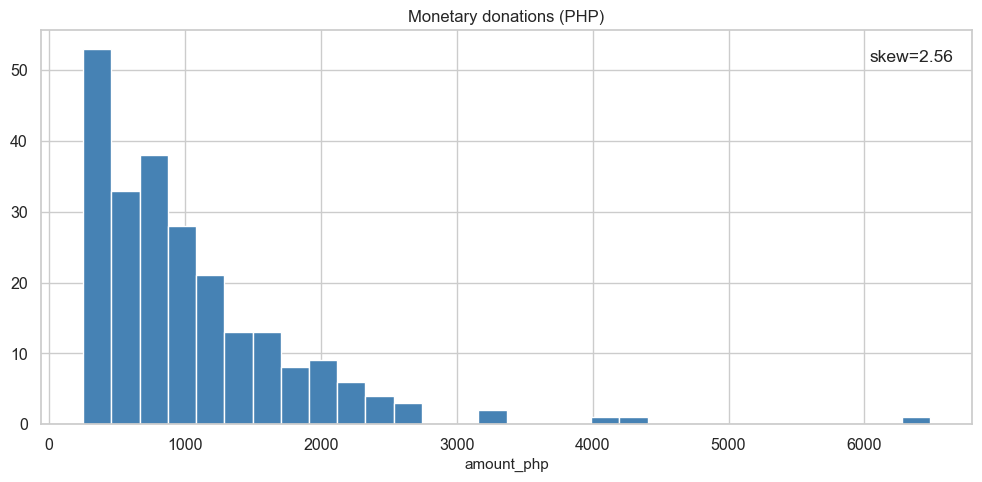

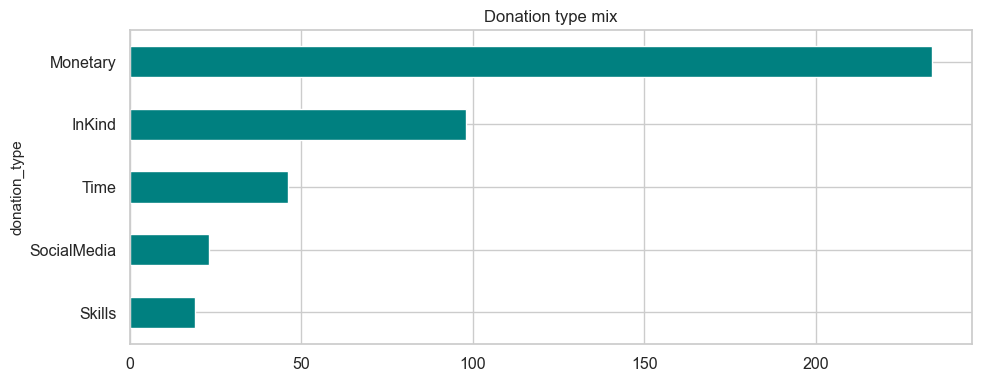

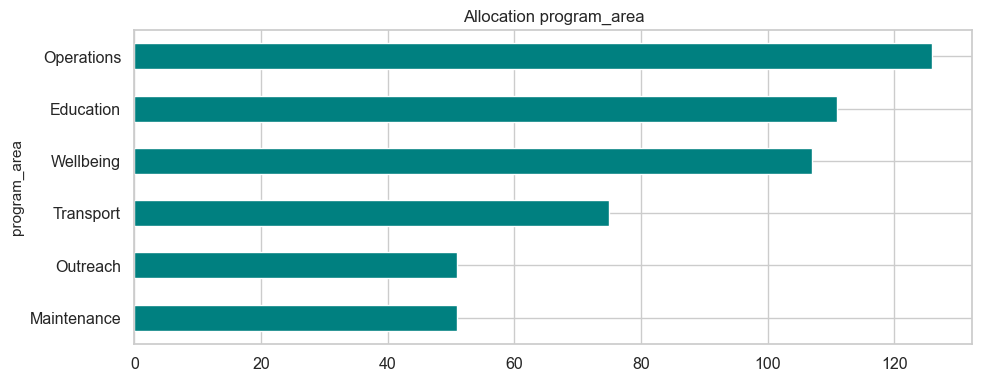

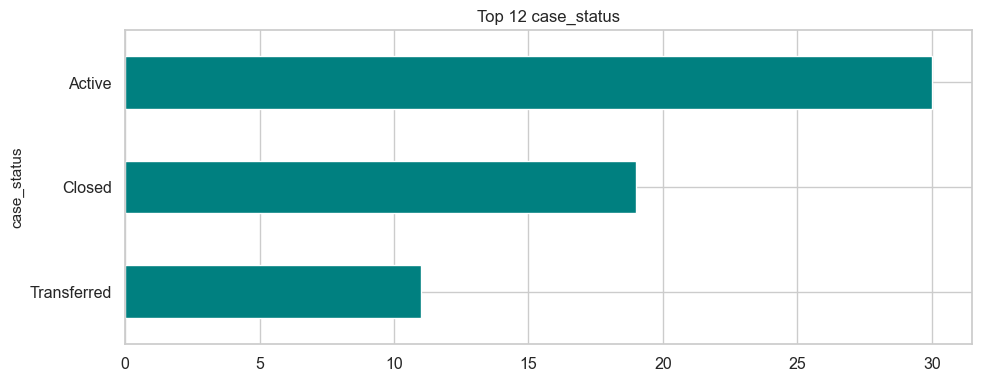

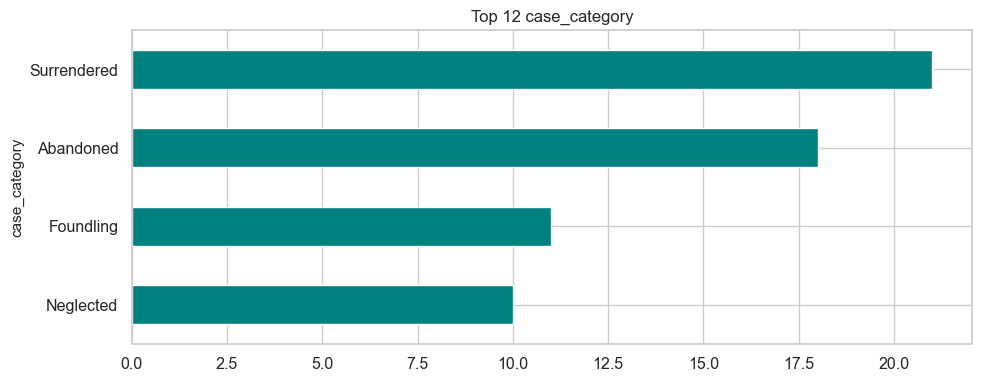

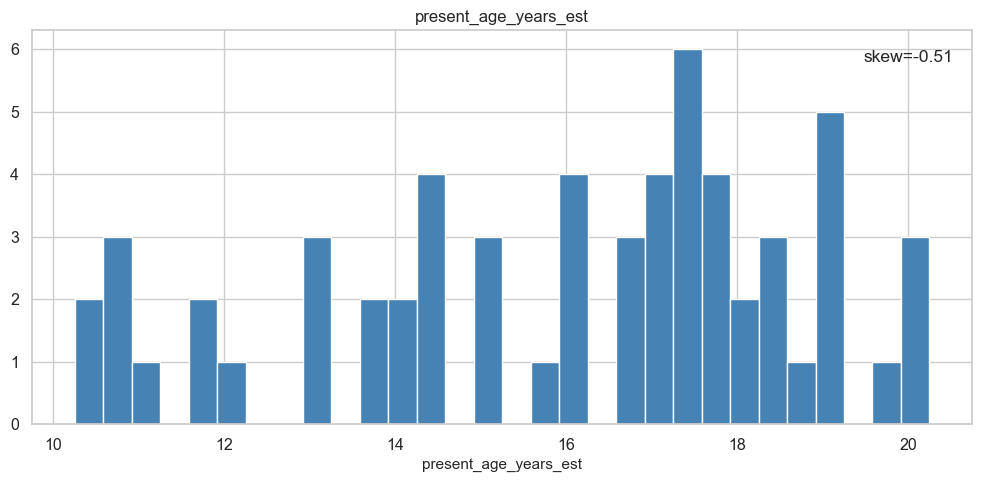

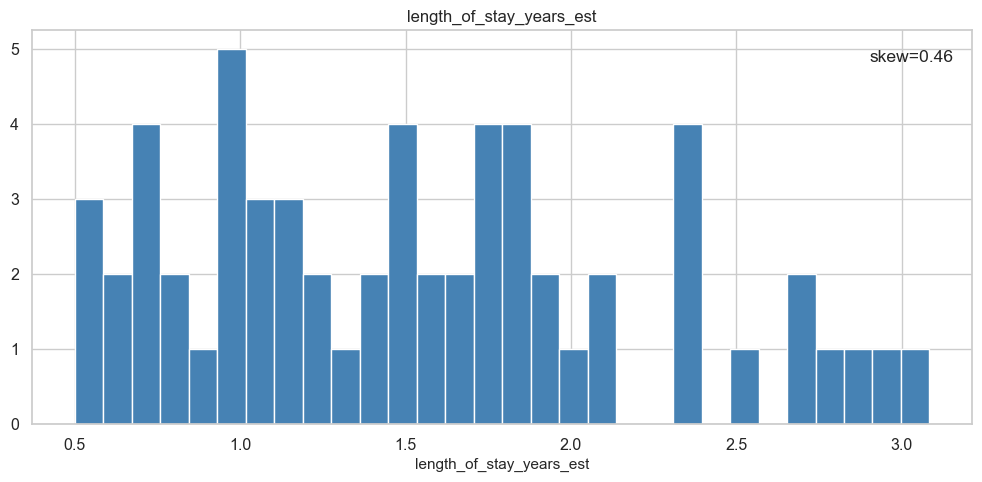

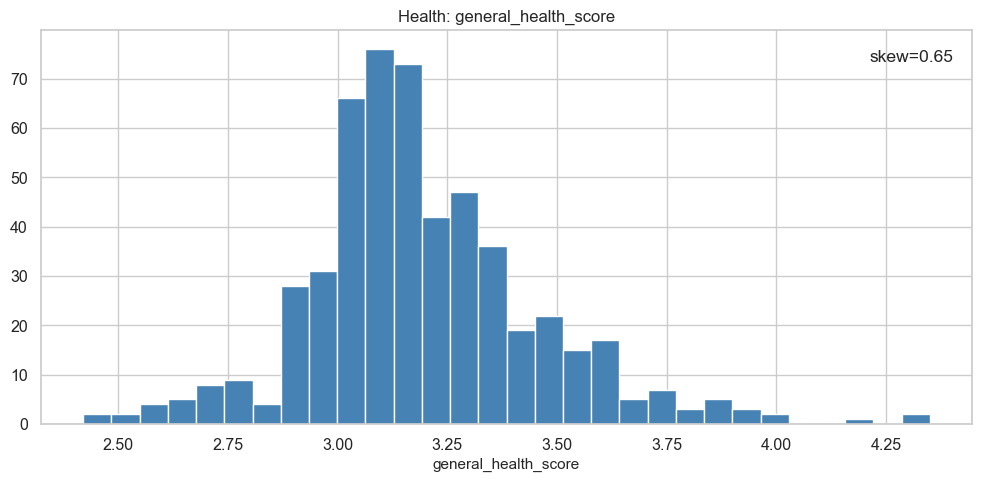

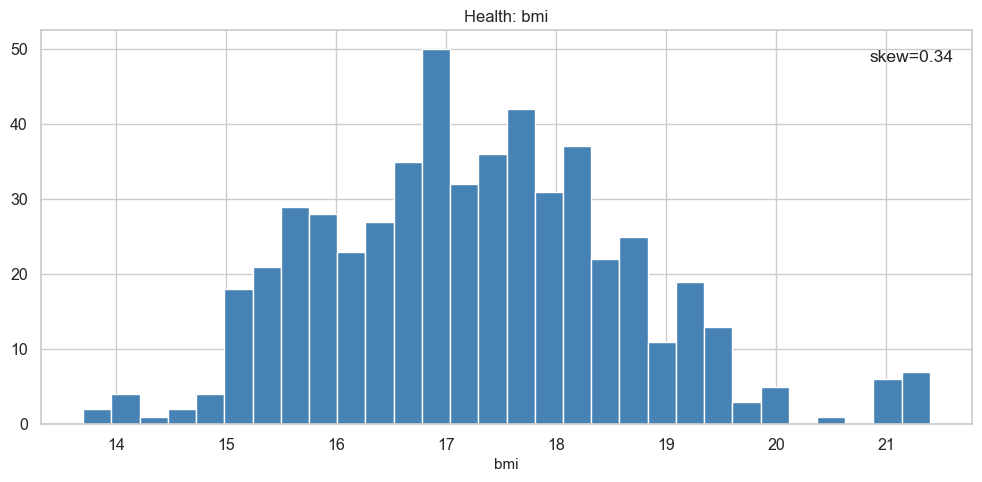

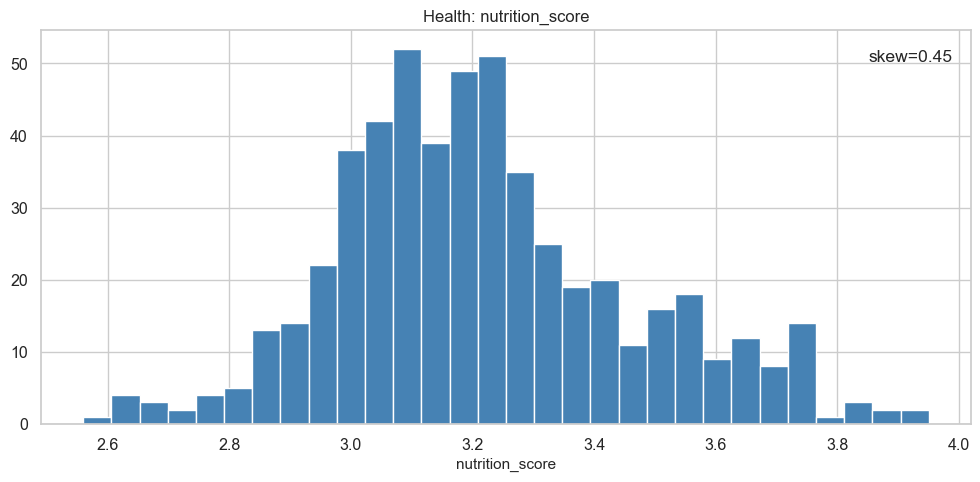

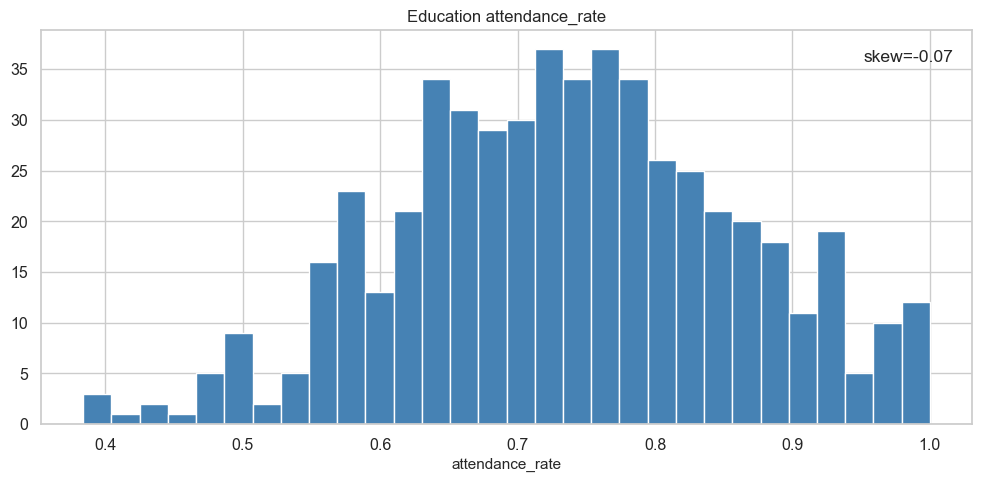

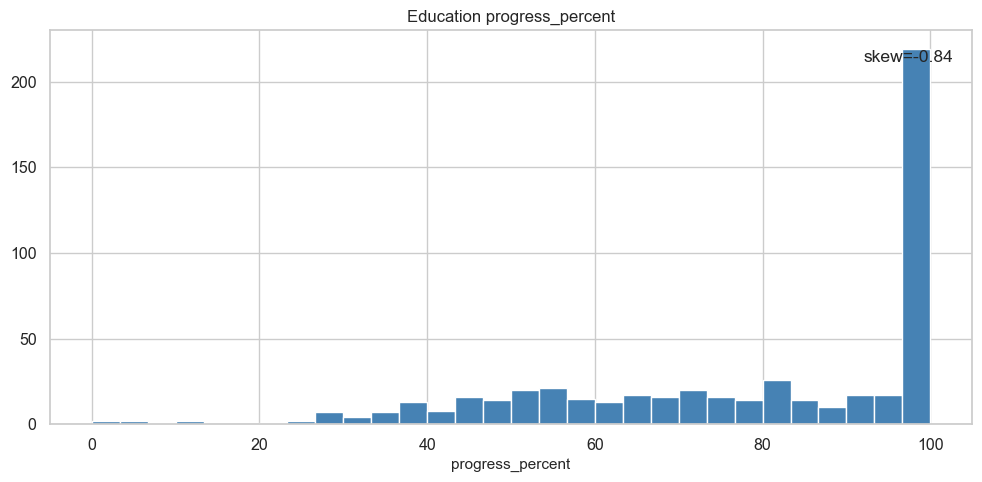

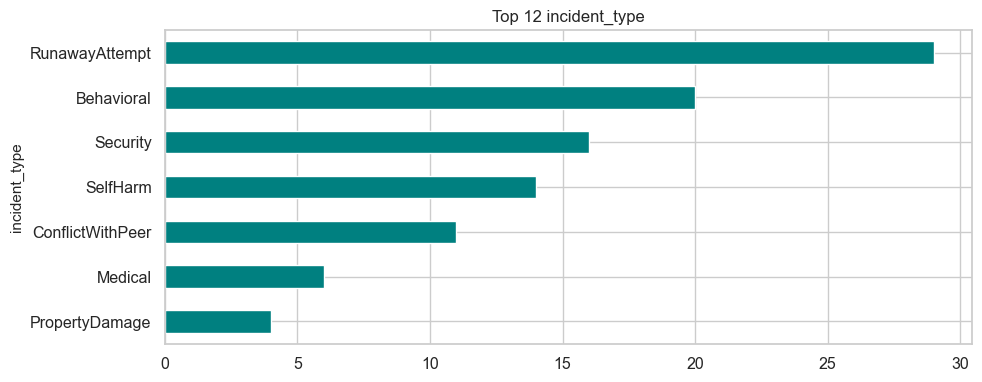

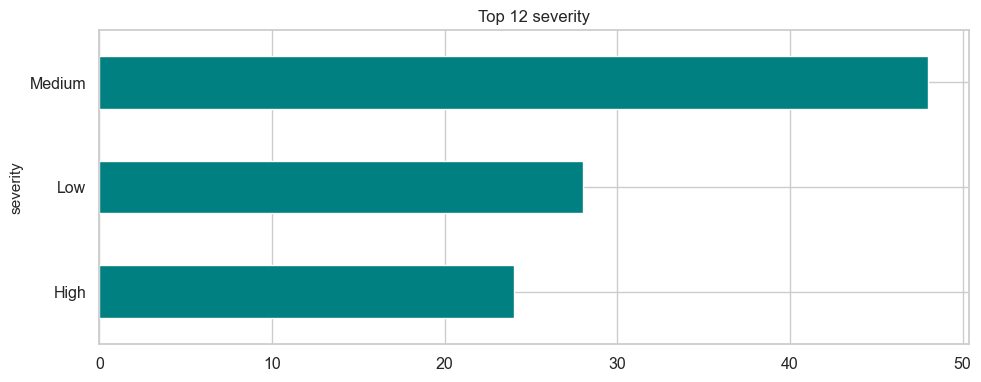

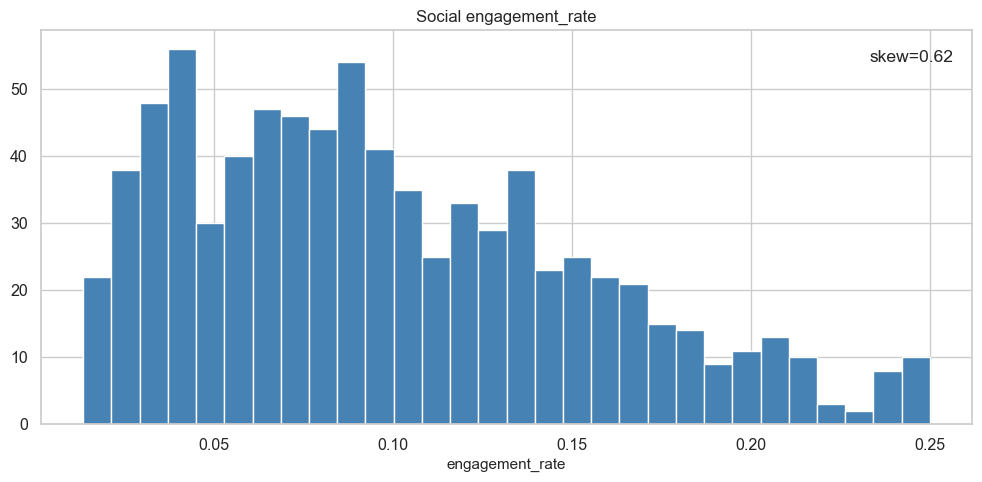

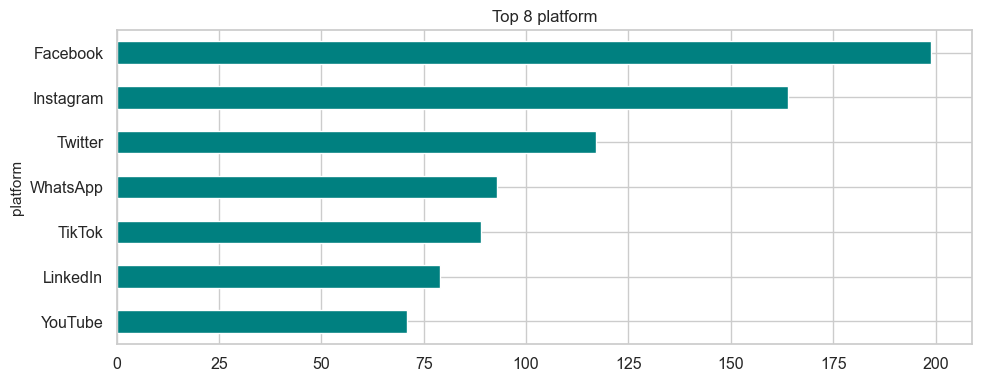

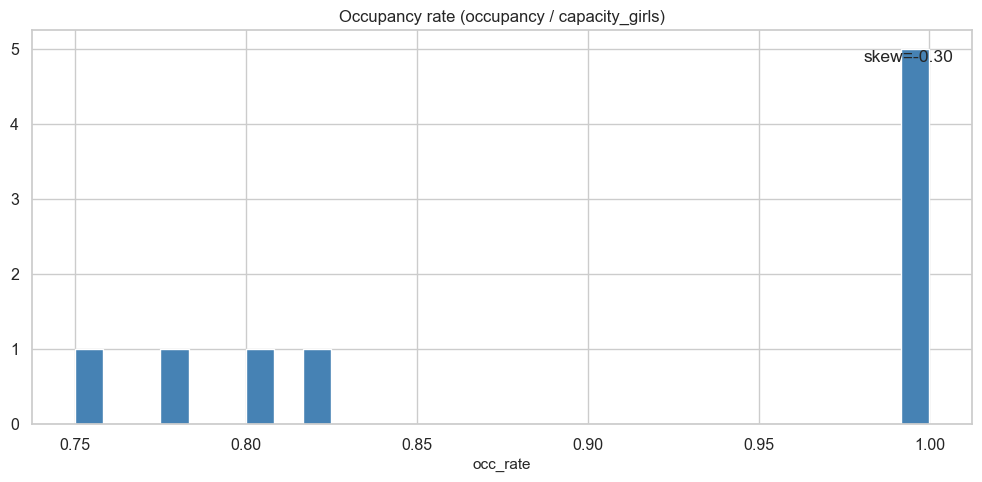

In [41]:
def hist_col(df, col, title=None, bins=30):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if s.empty:
        return
    fig, ax = plt.subplots()
    ax.hist(s, bins=bins, color="steelblue", edgecolor="white")
    ax.set_title(title or col)
    ax.set_xlabel(col)
    sk = skew(s)
    ax.text(0.98, 0.95, f"skew={sk:.2f}", transform=ax.transAxes, ha="right", va="top")
    plt.tight_layout()
    plt.show()


def bar_top(df, col, n=12, title=None):
    vc = df[col].astype(str).value_counts().head(n)
    fig, ax = plt.subplots(figsize=(10, 4))
    vc.plot(kind="barh", ax=ax, color="teal")
    ax.invert_yaxis()
    ax.set_title(title or f"Top {n} {col}")
    plt.tight_layout()
    plt.show()


# Donations: monetary amount
mon = dfs["donations"]["donation_type"].astype(str).str.lower().eq("monetary")
hist_col(dfs["donations"].loc[mon], "amount_php", "Monetary donations (PHP)")

bar_top(dfs["donations"], "donation_type", title="Donation type mix")
bar_top(dfs["donation_allocations"], "program_area", title="Allocation program_area")

# Residents
bar_top(dfs["residents"], "case_status")
bar_top(dfs["residents"], "case_category")
for c in ["present_age_years_est", "length_of_stay_years_est"]:
    if c in dfs["residents"].columns:
        hist_col(dfs["residents"], c, c)

# Health scores
for c in ["general_health_score", "bmi", "nutrition_score"]:
    if c in dfs["health_wellbeing_records"].columns:
        hist_col(dfs["health_wellbeing_records"], c, f"Health: {c}")

# Education
hist_col(dfs["education_records"], "attendance_rate", "Education attendance_rate")
hist_col(dfs["education_records"], "progress_percent", "Education progress_percent")

# Incidents
bar_top(dfs["incident_reports"], "incident_type")
bar_top(dfs["incident_reports"], "severity")

# Social
if "engagement_rate" in dfs["social_media_posts"].columns:
    hist_col(dfs["social_media_posts"], "engagement_rate", "Social engagement_rate")
bar_top(dfs["social_media_posts"], "platform", n=8)

# Safehouse occupancy vs capacity
sh = dfs["safehouses"].copy()
sh["occ_rate"] = sh["current_occupancy"] / sh["capacity_girls"].replace(0, np.nan)
hist_col(sh, "occ_rate", "Occupancy rate (occupancy / capacity_girls)")



### 3.1 Insights — univariate (**INTEX lens**)

- **Donations (Donor & support):** Right-skewed PHP amounts mirror **revenue concentration**—a few major relationships may carry the budget; the client’s worry about **who can give more** and **who might lapse** starts with knowing this mix. Keep **Monetary** separate from **Time** so “impact hours” are not confused with cash in stewardship and forecasting.
- **Residents (Case management):** Case category, status, and tenure describe **who the program serves**—essential for fair staffing expectations and for explaining **outcomes** to boards and donors in **aggregate**, anonymized terms.
- **Health / education:** Central tendency vs long tails flags **girls who may be slipping** relative to peers—aligned with “who is progressing vs struggling” and early warning before **reintegration** decisions.
- **Incidents:** Dominant types/severities drive **safety protocols** and training—directly about **protecting** residents across sites with thin management layers.
- **Social (Outreach):** Platform and engagement mix supports the case question: **where** to invest limited posting effort before tying posts to **donation attribution** (see sparse `referral_post_id` later).



## 4. Bivariate analysis

These relationships matter for **INTEX** because they connect **donor behavior** (channels, amounts), **resident wellbeing** (health vs education), **risk** (incidents), and **service delivery** (intervention plans)—the same levers your client must instrument in the app.

Each chart below is followed by **auto-generated summaries** so you do not have to read the heatmap “by eye”:

- **Numeric vs numeric:** tables of all pairs with Pearson r (linear) and Spearman ρ (rank), **p-values**, sample **n**, and a plain-language **strength** label.
- **Numeric vs categorical:** table of **count / median / mean** per group plus **Kruskal–Wallis** *H* and *p* (nonparametric test for “do distributions differ?”).
- **Categorical vs categorical:** **χ²** test and **Cramér’s V** (association strength, 0–1 scale).

**How to phrase findings:** report direction (positive/negative), strength tier, whether *p* < 0.05, and *n*—then add “association only; not proof of causation.”

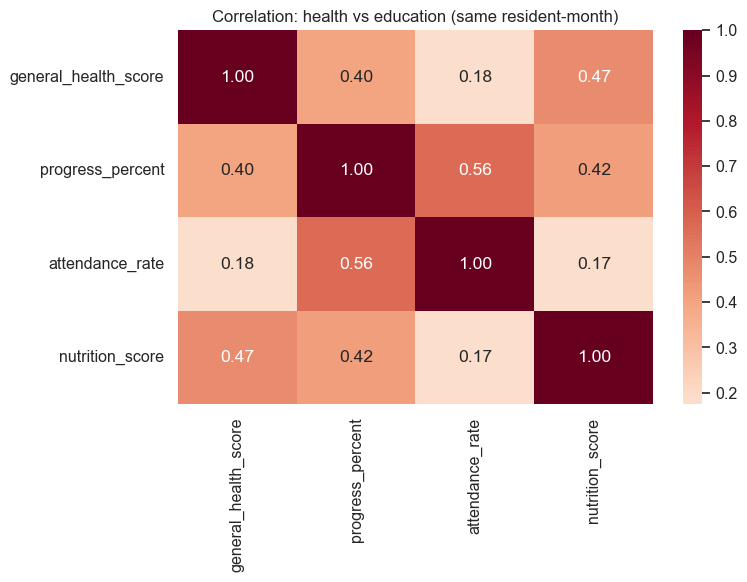

### Summary: health × education (same resident-month)
Top pairs by |Pearson r| (table); Spearman is robust to outliers / rank relationships.


,var_a,var_b,n,coefficient,abs_coefficient,p_value,strength
0,progress_percent,attendance_rate,534,0.5638,0.5638,3.926430e-46,strong
1,general_health_score,nutrition_score,534,0.4706,0.4706,8.786521e-31,moderate
2,progress_percent,nutrition_score,534,0.4151,0.4151,1.188555e-23,moderate
3,general_health_score,progress_percent,534,0.4015,0.4015,4.221755e-22,moderate
4,general_health_score,attendance_rate,534,0.1768,0.1768,3.995727e-05,weak
5,attendance_rate,nutrition_score,534,0.1745,0.1745,5.007749e-05,weak


,var_a,var_b,n,coefficient,abs_coefficient,p_value,strength
0,progress_percent,attendance_rate,534,0.5373,0.5373,2.817882e-41,strong
1,progress_percent,nutrition_score,534,0.4597,0.4597,2.796925e-29,moderate
2,general_health_score,progress_percent,534,0.4356,0.4356,3.869142e-26,moderate
3,general_health_score,nutrition_score,534,0.4307,0.4307,1.574324e-25,moderate
4,general_health_score,attendance_rate,534,0.2137,0.2137,6.253585e-07,weak
5,attendance_rate,nutrition_score,534,0.1836,0.1836,1.960752e-05,weak


→ Strongest linear link: **progress_percent** vs **attendance_rate** — r=0.564, p=3.926e-46, n=534 (strong; significant at α=0.05). Correlation ≠ causation; same-month rows can share confounders.


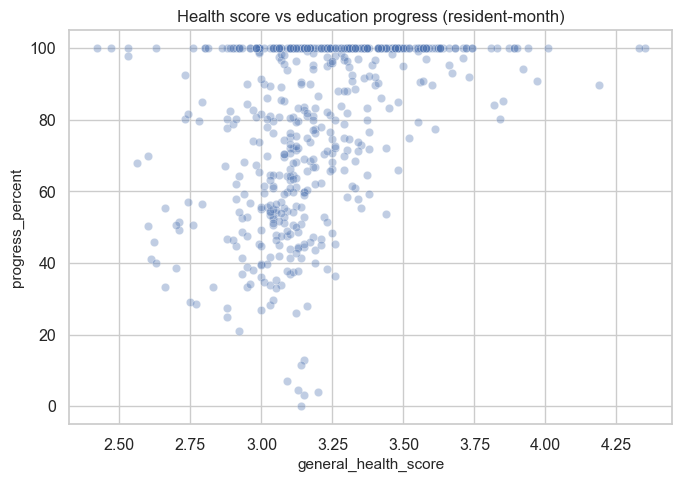

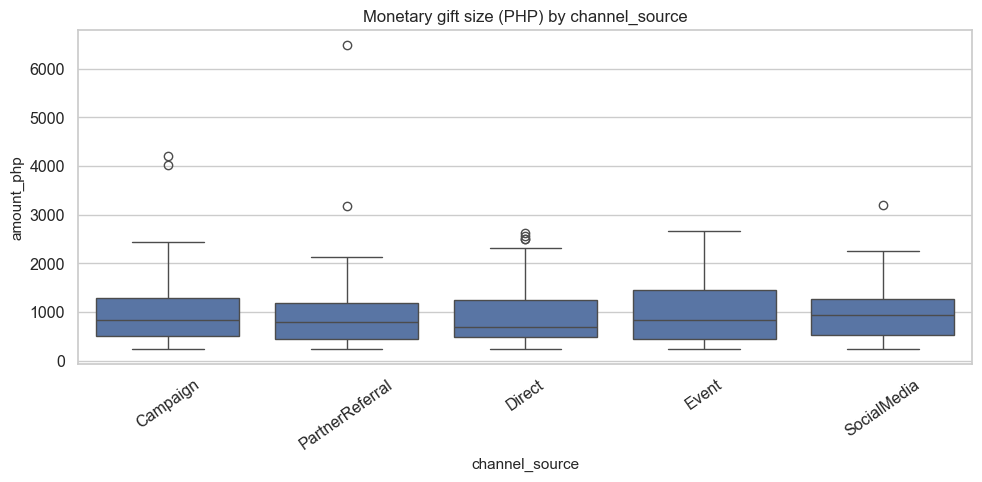

### Summary: gift size by channel (PHP)


,count,median,mean
channel_source,,,
SocialMedia,43,938.450,1013.743721
Event,48,847.080,993.141250
Campaign,71,835.010,1028.705634
PartnerReferral,28,800.665,1152.755357
Direct,44,693.050,1003.352955


→ Kruskal-Wallis across channels: H=0.212, p=0.9948 (small p suggests distributions differ; medians above show direction).


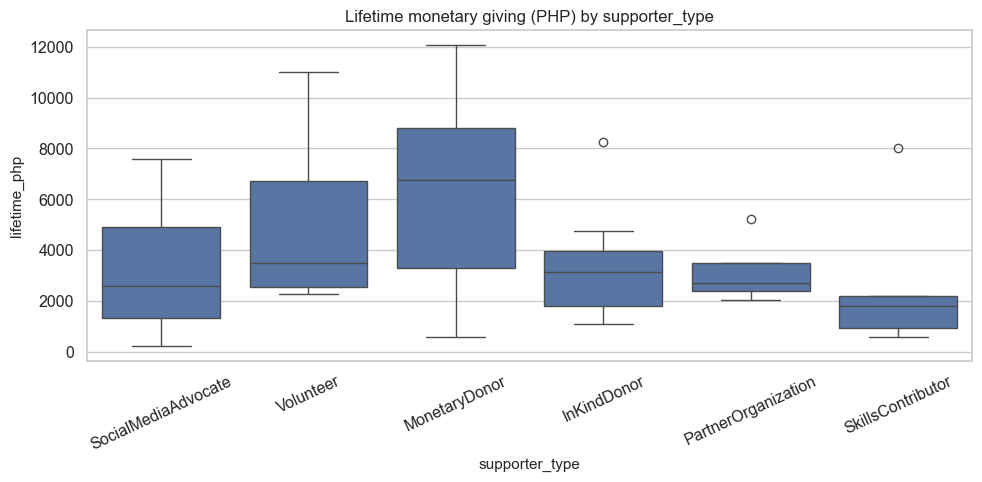

### Summary: lifetime PHP by supporter_type (per supporter)


,count,median,mean
supporter_type,,,
MonetaryDonor,16,6766.880,6091.710625
Volunteer,7,3480.080,5044.372857
InKindDonor,15,3157.760,3255.654667
PartnerOrganization,4,2724.835,3175.480000
SocialMediaAdvocate,10,2586.580,3288.845000
SkillsContributor,5,1804.690,2704.274000


→ Kruskal-Wallis: H=9.600, p=0.0874


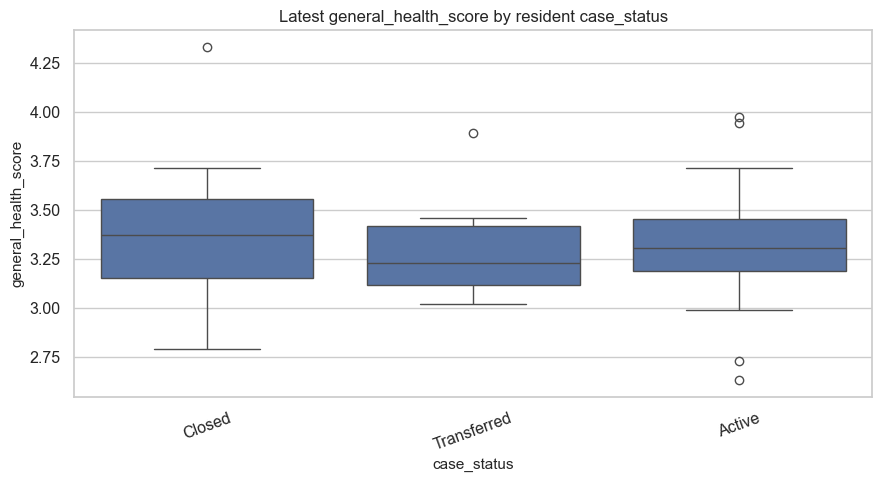

### Summary: latest health score by case_status


,count,median,mean
case_status,,,
Closed,19,3.370,3.367368
Active,30,3.305,3.315333
Transferred,11,3.230,3.294545


→ Kruskal-Wallis: H=0.805, p=0.6686


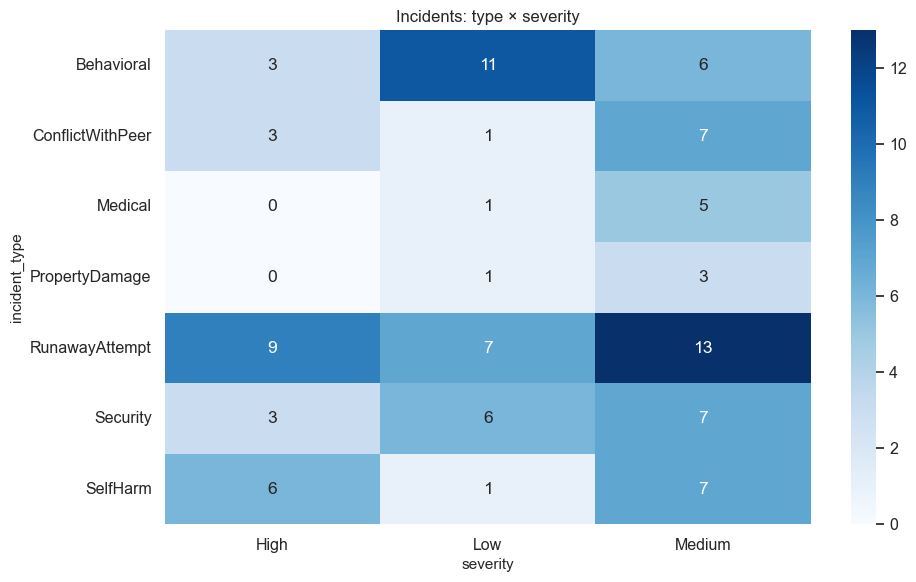


Association: incident_type × severity
  χ² = 19.94, df = 12, p = 0.0683
  Cramér's V ≈ 0.316 (0 = no association, up to ~1 = strong for this table size)
  Note: some expected counts < 5; treat p-value as approximate.


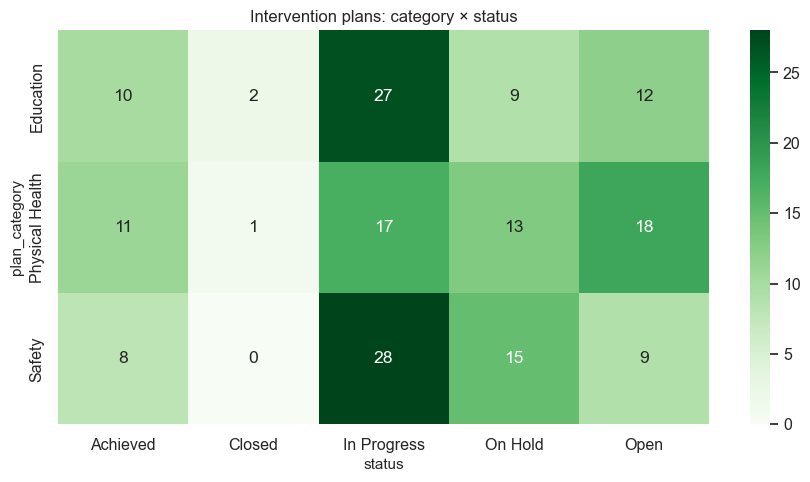


Association: plan_category × status
  χ² = 10.31, df = 8, p = 0.2439
  Cramér's V ≈ 0.169 (0 = no association, up to ~1 = strong for this table size)
  Note: some expected counts < 5; treat p-value as approximate.


In [42]:
mon = dfs["donations"]["donation_type"].astype(str).str.lower().eq("monetary")

# Numeric vs numeric: resident-month merge health + education on resident_id + period
h = dfs["health_wellbeing_records"].copy()
e = dfs["education_records"].copy()
h["ym"] = h["record_date"].dt.to_period("M").astype(str)
e["ym"] = e["record_date"].dt.to_period("M").astype(str)
he = h.merge(e, on=["resident_id", "ym"], suffixes=("_h", "_e"), how="inner")
cols = ["general_health_score", "progress_percent", "attendance_rate", "nutrition_score"]
cols = [c for c in cols if c in he.columns]
if len(cols) >= 2:
    corr = he[cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
    ax.set_title("Correlation: health vs education (same resident-month)")
    plt.tight_layout()
    plt.show()

    print("### Summary: health × education (same resident-month)")
    sp = pairwise_corr_summary(he, cols, method="pearson", min_obs=10)
    ss = pairwise_corr_summary(he, cols, method="spearman", min_obs=10)
    print("Top pairs by |Pearson r| (table); Spearman is robust to outliers / rank relationships.")
    display(sp)
    display(ss)
    if len(sp):
        top = sp.iloc[0]
        sig = "significant at α=0.05" if top["p_value"] < 0.05 else "not significant at α=0.05"
        print(
            f"→ Strongest linear link: **{top['var_a']}** vs **{top['var_b']}** — r={top['coefficient']:.3f}, "
            f"p={top['p_value']:.4g}, n={int(top['n'])} ({top['strength']}; {sig}). "
            "Correlation ≠ causation; same-month rows can share confounders."
        )

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=he.sample(min(800, len(he)), random_state=RANDOM_STATE), x="general_health_score", y="progress_percent", alpha=0.35, ax=ax)
    ax.set_title("Health score vs education progress (resident-month)")
    plt.tight_layout()
    plt.show()

# Categorical vs numeric: monetary amount by channel
dmon = dfs["donations"].loc[mon].copy()
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=dmon, x="channel_source", y="amount_php", ax=ax)
ax.set_title("Monetary gift size (PHP) by channel_source")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

tbl_ch, kw_ch = numeric_by_category_summary(dmon, "amount_php", "channel_source", min_per_group=3)
print("### Summary: gift size by channel (PHP)")
if tbl_ch is not None:
    display(tbl_ch)
if kw_ch:
    print(f"→ Kruskal-Wallis across channels: H={kw_ch['H']:.3f}, p={kw_ch['p_value']:.4g} "
          "(small p suggests distributions differ; medians above show direction).")

# Supporter type vs total given (aggregated)
tot = dmon.groupby("supporter_id")["amount_php"].sum().reset_index(name="lifetime_php")
tot = tot.merge(dfs["supporters"], on="supporter_id", how="left")
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=tot, x="supporter_type", y="lifetime_php", ax=ax)
ax.set_title("Lifetime monetary giving (PHP) by supporter_type")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

tbl_st, kw_st = numeric_by_category_summary(tot, "lifetime_php", "supporter_type", min_per_group=3)
print("### Summary: lifetime PHP by supporter_type (per supporter)")
if tbl_st is not None:
    display(tbl_st)
if kw_st:
    print(f"→ Kruskal-Wallis: H={kw_st['H']:.3f}, p={kw_st['p_value']:.4g}")

# Health score by case_status (latest record per resident)
last_h = dfs["health_wellbeing_records"].sort_values("record_date").groupby("resident_id").tail(1)
last_h = last_h.merge(dfs["residents"][["resident_id", "case_status"]], on="resident_id")
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=last_h, x="case_status", y="general_health_score", ax=ax)
ax.set_title("Latest general_health_score by resident case_status")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

tbl_cs, kw_cs = numeric_by_category_summary(last_h, "general_health_score", "case_status", min_per_group=3)
print("### Summary: latest health score by case_status")
if tbl_cs is not None:
    display(tbl_cs)
if kw_cs:
    print(f"→ Kruskal-Wallis: H={kw_cs['H']:.3f}, p={kw_cs['p_value']:.4g}")

# Crosstab: incident type x severity
ct = pd.crosstab(dfs["incident_reports"]["incident_type"], dfs["incident_reports"]["severity"])
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Incidents: type × severity")
plt.tight_layout()
plt.show()

crosstab_chi2_summary(ct, "Association: incident_type × severity")

# Intervention plan category × status
ct2 = pd.crosstab(dfs["intervention_plans"]["plan_category"], dfs["intervention_plans"]["status"])
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct2, annot=True, fmt="d", cmap="Greens", ax=ax)
ax.set_title("Intervention plans: category × status")
plt.tight_layout()
plt.show()

crosstab_chi2_summary(ct2, "Association: plan_category × status")




### 4.1 Insights — bivariate (**INTEX lens** + how to read the tables)

Use the **printed tables and p-values** from the code cell above in memos and dashboards.

- **Health × education (same month):** For the **case-management** app, a coherent positive association supports a **single resident timeline** UI (wellbeing + schooling move together). If correlation is weak, staff may still need **separate alerts** (education can stall while health looks stable). Always cite *r* / *ρ*, *p*, and *n*; Spearman vs Pearson divergence hints at **outliers** or nonlinear progress—relevant for **who needs escalation**.
- **Channel / supporter type vs gift size:** Feeds **Donor & support** segmentation: which **acquisition** or **appeal** routes produce different gift distributions (medians + Kruskal–Wallis). That informs **campaign experiments** and “who to ask for what” without a marketing department—test and measure, don’t assume causality.
- **Case status vs latest health:** Connects **operational status** to **wellbeing metrics**—useful for staff prioritization and, in **aggregated** form, for **donor impact** narratives (“active cases show stable health tracking”).
- **Incidents × severity; plans × status:** **Cramér’s V** and χ² support **risk management** and **intervention pipeline** reviews (e.g. many plans “On Hold” → case-conference capacity). Tie to the case’s need to see **which interventions are moving** vs stuck.



## 5. Multivariate analysis

Aggregated **safehouse-level** features: correlation heatmap, **pairwise summary table** (few sites → interpret cautiously), K-means elbow + clusters, and PCA with a **loadings** table plus short text on what PC1 and PC2 represent.

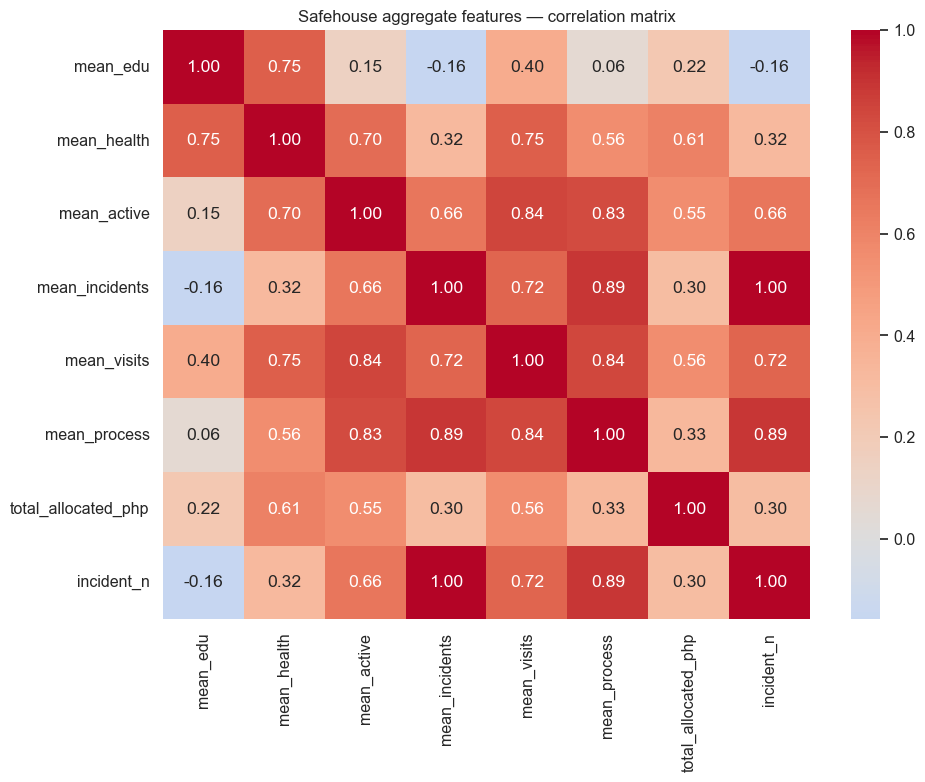

### Summary: safehouse-level correlations (n=9 sites — interpret cautiously)


,var_a,var_b,n,coefficient,abs_coefficient,p_value,strength
0,mean_incidents,incident_n,9,1.0000,1.0000,5.371281e-55,very strong
1,mean_process,incident_n,9,0.8936,0.8936,1.163682e-03,very strong
2,mean_incidents,mean_process,9,0.8936,0.8936,1.163682e-03,very strong
3,mean_active,mean_visits,9,0.8441,0.8441,4.215353e-03,very strong
4,mean_visits,mean_process,9,0.8407,0.8407,4.528386e-03,very strong
5,mean_active,mean_process,9,0.8252,0.8252,6.171728e-03,very strong
6,mean_health,mean_visits,9,0.7524,0.7524,1.932300e-02,very strong
7,mean_edu,mean_health,9,0.7509,0.7509,1.972103e-02,very strong
8,mean_incidents,mean_visits,9,0.7241,0.7241,2.737983e-02,very strong
9,mean_visits,incident_n,9,0.7241,0.7241,2.737983e-02,very strong


→ Largest |r|: **mean_incidents** vs **incident_n**, r=1.000, p=5.371e-55. With few sites, one outlier can dominate; use for hypotheses, not proof.


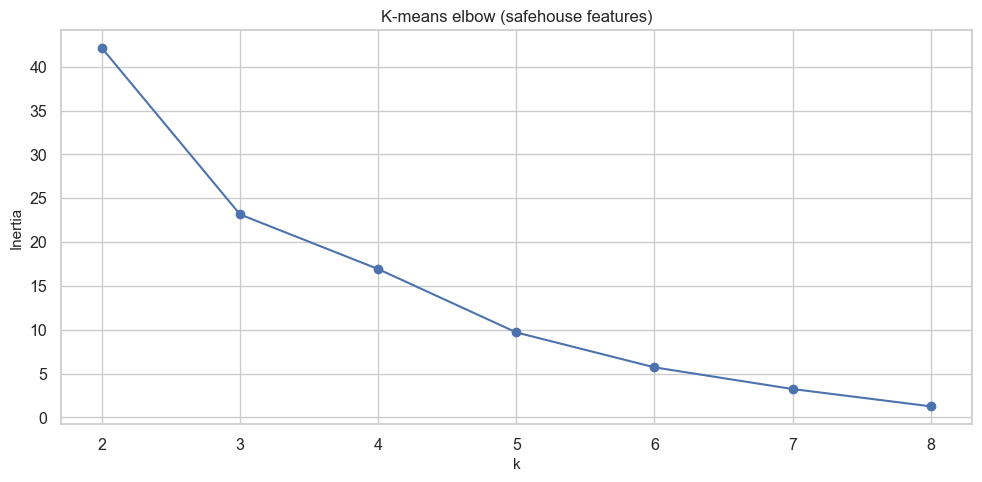

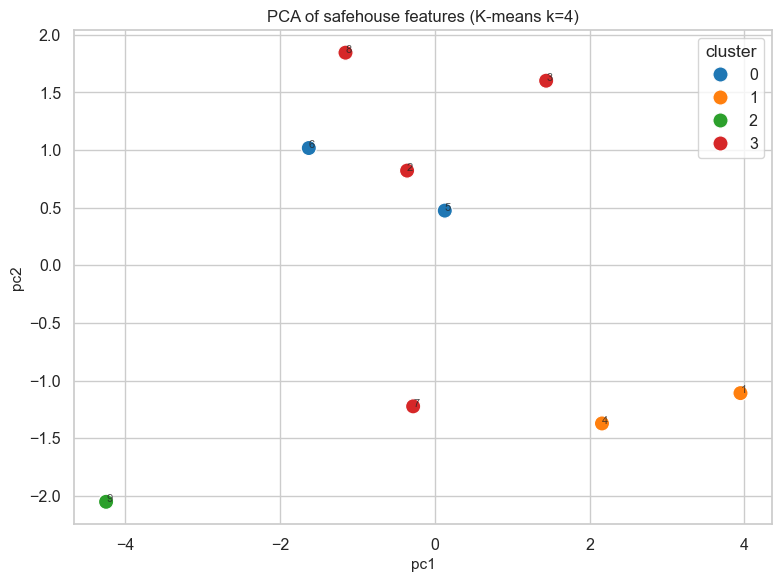

PCA explained variance ratio: [0.61966954 0.2320848 ]
### Summary: what drives PC1 / PC2 (loadings; scale is relative)


,PC1_loading,PC2_loading
mean_edu,0.112,0.645
mean_health,0.335,0.463
mean_active,0.404,0.022
mean_incidents,0.378,-0.361
mean_visits,0.426,0.106
mean_process,0.417,-0.183
total_allocated_php,0.267,0.252
incident_n,0.378,-0.361


→ PC1 (62.0% variance): dominated by mean_visits (+0.43), mean_process (+0.42), mean_active (+0.40)
→ PC2 (23.2% variance): dominated by mean_edu (+0.65), mean_health (+0.46), incident_n (-0.36)


,safehouse_id,mean_edu,mean_health,mean_active,mean_incidents,mean_visits,mean_process,total_allocated_php,incident_n,cluster,pc1,pc2
0,1,78.005000,3.262222,10.0,0.40,5.26,10.18,34689.26,20,1,3.950060,-1.108840
1,2,78.071724,3.206897,8.0,0.16,2.76,5.18,34363.02,8,3,-0.359207,0.820909
2,3,84.035000,3.391786,7.0,0.24,3.52,6.00,50574.33,12,3,1.438267,1.600543
3,4,72.312759,3.234483,8.0,0.34,3.50,9.62,34335.76,17,1,2.159767,-1.371899
4,5,84.339200,3.208000,6.0,0.22,3.18,7.50,23996.23,11,0,0.127864,0.473977
5,6,84.997333,3.209667,5.0,0.16,2.14,4.38,19214.62,8,0,-1.629858,1.016595
6,7,68.283333,3.036000,8.0,0.22,2.40,6.72,30196.11,11,3,-0.281157,-1.223623
7,8,83.380968,3.200323,6.0,0.10,3.12,4.48,34134.29,5,3,-1.155586,1.843720
8,9,65.670000,2.617333,2.0,0.16,0.86,2.32,20932.77,8,2,-4.250151,-2.051382


In [43]:
# Safehouse-level panel from monthly metrics
m = dfs["safehouse_monthly_metrics"].copy()
m["ym"] = m["month_start"].dt.to_period("M").astype(str)

agg = m.groupby("safehouse_id").agg(
    mean_edu=("avg_education_progress", "mean"),
    mean_health=("avg_health_score", "mean"),
    mean_active=("active_residents", "mean"),
    mean_incidents=("incident_count", "mean"),
    mean_visits=("home_visitation_count", "mean"),
    mean_process=("process_recording_count", "mean"),
).reset_index()

# Donations allocated per safehouse
alloc = dfs["donation_allocations"].groupby("safehouse_id")["amount_allocated"].sum().reset_index(name="total_allocated_php")
agg = agg.merge(alloc, on="safehouse_id", how="left").fillna({"total_allocated_php": 0})

# Incidents per safehouse (all time)
inc = dfs["incident_reports"].groupby("safehouse_id").size().reset_index(name="incident_n")
agg = agg.merge(inc, on="safehouse_id", how="left").fillna({"incident_n": 0})

feat_cols = ["mean_edu", "mean_health", "mean_active", "mean_incidents", "mean_visits", "mean_process", "total_allocated_php", "incident_n"]
X = agg[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

corr2 = X.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Safehouse aggregate features — correlation matrix")
plt.tight_layout()
plt.show()

n_sites = len(X)
print(f"### Summary: safehouse-level correlations (n={n_sites} sites — interpret cautiously)")
sh_pairs = pairwise_corr_summary(X, feat_cols, method="pearson", min_obs=max(4, min(5, n_sites - 1)))
display(sh_pairs)
if len(sh_pairs):
    top = sh_pairs.iloc[0]
    print(
        f"→ Largest |r|: **{top['var_a']}** vs **{top['var_b']}**, r={top['coefficient']:.3f}, "
        f"p={top['p_value']:.4g}. With few sites, one outlier can dominate; use for hypotheses, not proof."
    )

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

scaler = StandardScaler()
Xs = scaler.fit_transform(X)
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(Xs)
    inertias.append(km.inertia_)
fig, ax = plt.subplots()
ax.plot(list(K_range), inertias, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Inertia")
ax.set_title("K-means elbow (safehouse features)")
plt.tight_layout()
plt.show()

k_best = 4
km = KMeans(n_clusters=k_best, random_state=RANDOM_STATE, n_init=10)
agg["cluster"] = km.fit_predict(Xs)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(Xs)
agg["pc1"], agg["pc2"] = Z[:, 0], Z[:, 1]
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=agg, x="pc1", y="pc2", hue="cluster", palette="tab10", s=120, ax=ax)
for _, r in agg.iterrows():
    ax.annotate(str(int(r["safehouse_id"])), (r["pc1"], r["pc2"]), fontsize=8, alpha=0.8)
ax.set_title(f"PCA of safehouse features (K-means k={k_best})")
plt.tight_layout()
plt.show()

evr = pca.explained_variance_ratio_
print("PCA explained variance ratio:", evr)
loadings = pd.DataFrame(pca.components_.T, index=feat_cols, columns=["PC1_loading", "PC2_loading"])
print("### Summary: what drives PC1 / PC2 (loadings; scale is relative)")
display(loadings.round(3))
pc1_top = loadings["PC1_loading"].abs().sort_values(ascending=False).head(3)
pc2_top = loadings["PC2_loading"].abs().sort_values(ascending=False).head(3)
print(
    f"→ PC1 ({100 * evr[0]:.1f}% variance): dominated by "
    + ", ".join(f"{i} ({loadings.loc[i, 'PC1_loading']:+.2f})" for i in pc1_top.index)
)
print(
    f"→ PC2 ({100 * evr[1]:.1f}% variance): dominated by "
    + ", ".join(f"{i} ({loadings.loc[i, 'PC2_loading']:+.2f})" for i in pc2_top.index)
)

display(agg.sort_values("safehouse_id"))



### 5.1 Insights — multivariate (**INTEX lens**)

- **Safehouse correlations:** With **few sites**, any correlation is **hypothesis-generating** for regional leads: e.g. high **incident rate** co-moving with **visit counts** might mean intense supervision—or reporting norms—not necessarily “worse” care. The client’s **multi-site, thin management** story means leadership needs **normalized** comparisons (per resident-month), not raw counts alone.
- **Clusters / PCA:** Useful for **peer benchmarking** (“sites like mine”) and for deciding where to **share playbooks** or **add supervision**. For the **admin dashboard** in the case spec, this suggests showing **site cluster** or **relative position** on 1–2 composite scores—not raw overload.

---
## 6. Cross-table analysis (joins)

Residents + health + education + interventions; donations + supporters + allocations; safehouses + incidents + metrics; social referral linkage.



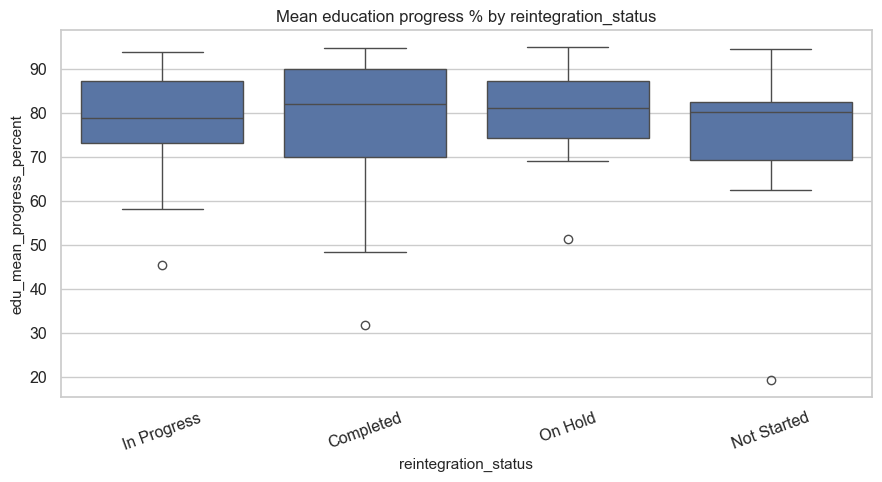

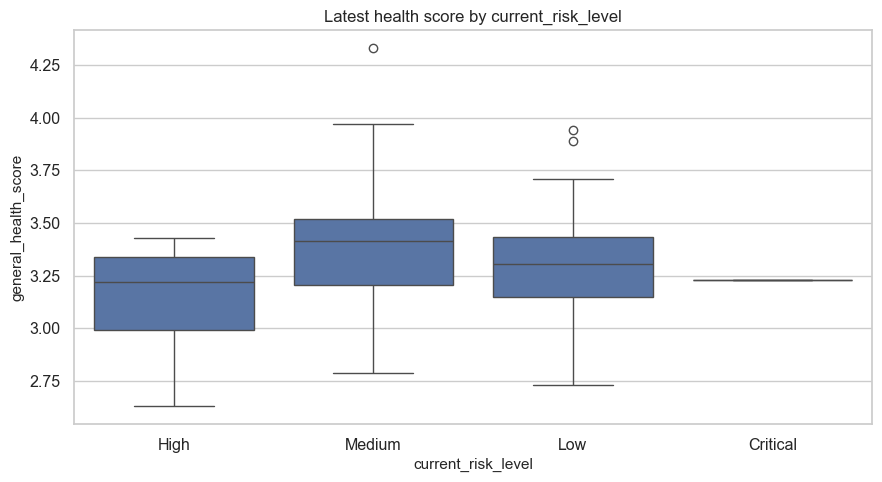

Top-decile threshold PHP: 8817.42 | n high-value: 6


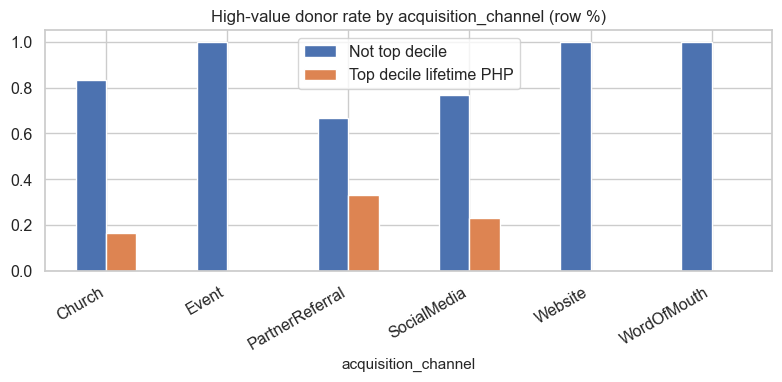

,safehouse_id,mean_incident_rate,mean_edu,name,region
5,6,0.032000,84.997333,Lighthouse Safehouse 6,Mindanao
4,5,0.036667,84.339200,Lighthouse Safehouse 5,Luzon
2,3,0.034286,84.035000,Lighthouse Safehouse 3,Mindanao
7,8,0.016667,83.380968,Lighthouse Safehouse 8,Visayas
1,2,0.020000,78.071724,Lighthouse Safehouse 2,Visayas
0,1,0.040000,78.005000,Lighthouse Safehouse 1,Luzon
3,4,0.042500,72.312759,Lighthouse Safehouse 4,Visayas
6,7,0.027500,68.283333,Lighthouse Safehouse 7,Visayas
8,9,0.080000,65.670000,Lighthouse Safehouse 9,Mindanao


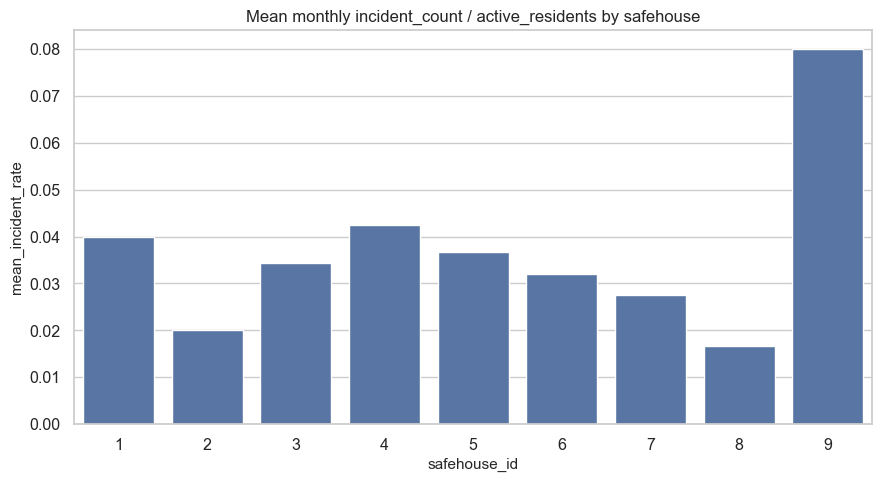

has_referral
False    343
True      77
dtype: int64
Attributed donation rows: 77


,donation_id,amount_php,platform,engagement_rate,donation_referrals
0,5,NaN,YouTube,0.0898,4
1,25,1796.47,WhatsApp,0.0944,28
2,29,1014.15,TikTok,0.1800,19
3,30,NaN,TikTok,0.2052,63
4,32,NaN,Facebook,0.0781,4
5,34,938.45,TikTok,0.1884,148
6,36,766.29,YouTube,0.0898,4
7,65,NaN,LinkedIn,0.1775,14
8,73,1967.06,Instagram,0.1850,18
9,75,NaN,Instagram,0.0849,86


In [44]:
# --- 6.1 Resident-level outcomes vs aggregated longitudinal features ---
last_h = dfs["health_wellbeing_records"].sort_values("record_date").groupby("resident_id").tail(1).set_index("resident_id")
mean_h = dfs["health_wellbeing_records"].groupby("resident_id")["general_health_score"].mean()
last_e = dfs["education_records"].sort_values("record_date").groupby("resident_id").tail(1).set_index("resident_id")
mean_e = dfs["education_records"].groupby("resident_id")[["attendance_rate", "progress_percent"]].mean()

ip = dfs["intervention_plans"].groupby("resident_id").agg(
    n_plans=("plan_id", "count"),
    pct_completed=("status", lambda s: (s.astype(str).str.lower().eq("completed")).mean()),
)

res_feat = dfs["residents"].set_index("resident_id")
for name, s in [("health_last", last_h["general_health_score"]), ("health_mean", mean_h)]:
    res_feat = res_feat.join(s.rename(name), how="left")
res_feat = res_feat.join(mean_e.add_prefix("edu_mean_"), how="left")
res_feat = res_feat.join(last_e[["progress_percent"]].rename(columns={"progress_percent": "edu_progress_last"}), how="left")
res_feat = res_feat.join(ip, how="left")

# Simple association: reintegration_status vs mean progress
sub = res_feat.dropna(subset=["reintegration_status", "edu_mean_progress_percent"])
if len(sub) > 5:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=sub.reset_index(), x="reintegration_status", y="edu_mean_progress_percent", ax=ax)
    ax.set_title("Mean education progress % by reintegration_status")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# Risk level vs latest health
sub2 = res_feat.reset_index().merge(
    dfs["health_wellbeing_records"].sort_values("record_date").groupby("resident_id").tail(1)[["resident_id", "general_health_score"]],
    on="resident_id",
    how="left",
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=sub2, x="current_risk_level", y="general_health_score", ax=ax)
ax.set_title("Latest health score by current_risk_level")
plt.tight_layout()
plt.show()

# --- 6.2 High-value donors (top decile lifetime monetary) ---
mon = dfs["donations"]["donation_type"].astype(str).str.lower().eq("monetary")
dmon = dfs["donations"].loc[mon].copy()
life = dmon.groupby("supporter_id")["amount_php"].sum().reset_index(name="lifetime_php")
life = life.merge(dfs["supporters"], on="supporter_id", how="left")
q90 = life["lifetime_php"].quantile(0.9)
life["high_value"] = life["lifetime_php"] >= q90
print("Top-decile threshold PHP:", round(q90, 2), "| n high-value:", int(life["high_value"].sum()))

fig, ax = plt.subplots(figsize=(8, 4))
pd.crosstab(life["acquisition_channel"], life["high_value"], normalize="index").plot(kind="bar", ax=ax)
ax.set_title("High-value donor rate by acquisition_channel (row %)")
ax.legend(["Not top decile", "Top decile lifetime PHP"])
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# --- 6.3 Safehouse performance: incidents per active resident-month ---
mm = dfs["safehouse_monthly_metrics"].copy()
mm["incident_rate"] = mm["incident_count"] / mm["active_residents"].replace(0, np.nan)
perf = mm.groupby("safehouse_id").agg(mean_incident_rate=("incident_rate", "mean"), mean_edu=("avg_education_progress", "mean")).reset_index()
perf = perf.merge(dfs["safehouses"][["safehouse_id", "name", "region"]], on="safehouse_id")
display(perf.sort_values("mean_edu", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=perf.sort_values("mean_incident_rate", ascending=False), x="safehouse_id", y="mean_incident_rate", ax=ax)
ax.set_title("Mean monthly incident_count / active_residents by safehouse")
plt.tight_layout()
plt.show()

# --- 6.4 Social attribution ---
dall = dfs["donations"].copy()
dall["has_referral"] = dall["referral_post_id"].notna()
print(dall.groupby("has_referral").size())
ref_df = dall.dropna(subset=["referral_post_id"]).merge(
    dfs["social_media_posts"], left_on="referral_post_id", right_on="post_id", how="left", suffixes=("_don", "_post")
)
print("Attributed donation rows:", len(ref_df))
if len(ref_df):
    display(ref_df[["donation_id", "amount_php", "platform", "engagement_rate", "donation_referrals"]].head(10))



### 6.1 Insights — cross-table (**INTEX lens**)

- **Residents + health + education + interventions:** Joints support the case lifecycle: **intake → services → reintegration**. Patterns by `reintegration_status` or `current_risk_level` inform **which girls need more touchpoints** and what to emphasize in **case conferences**—always framed as associations, not proof a single service “caused” an outcome.
- **Donors + supporters + allocations:** **High-value** and **channel** patterns feed **retention**, **upgrade asks**, and **lapse-risk** models the client asked for. **Allocations by program area** are a bridge to **“your gift funded X”** messaging on an **Impact** page (anonymized rollups only).
- **Safehouses + incidents + metrics:** **Incidents per active resident** supports fair **resource allocation** across houses when the org scales—aligned with “limited staff managing multiple safehouses.”
- **Social ↔ donations:** Sparse `referral_post_id` is expected today; fixing capture (UTMs, post IDs at checkout) is a **product requirement** to answer “what content actually leads to donations”—core to the **Outreach** domain in the case.

---
## 7. Time-based analysis

Trends in donations, incidents, and aggregate health/education from monthly metrics and snapshots.



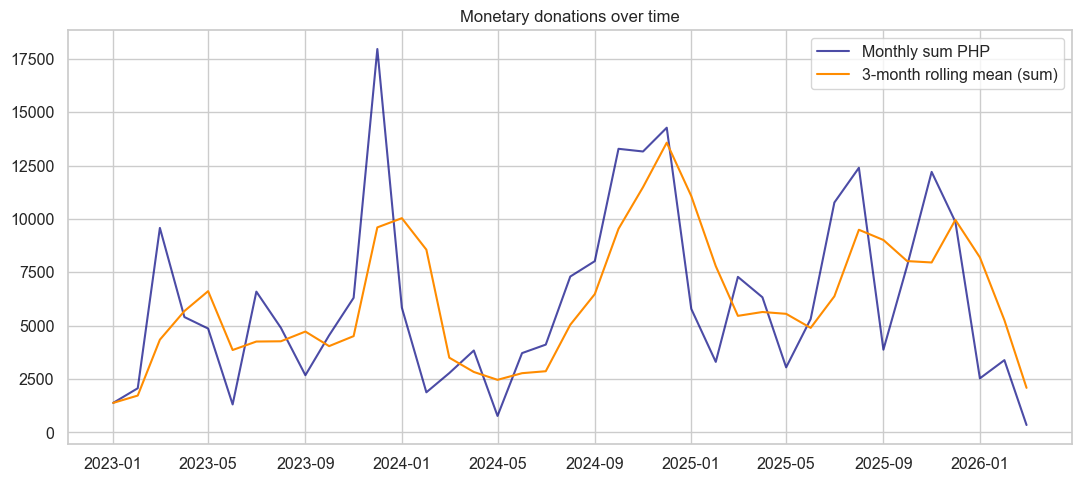

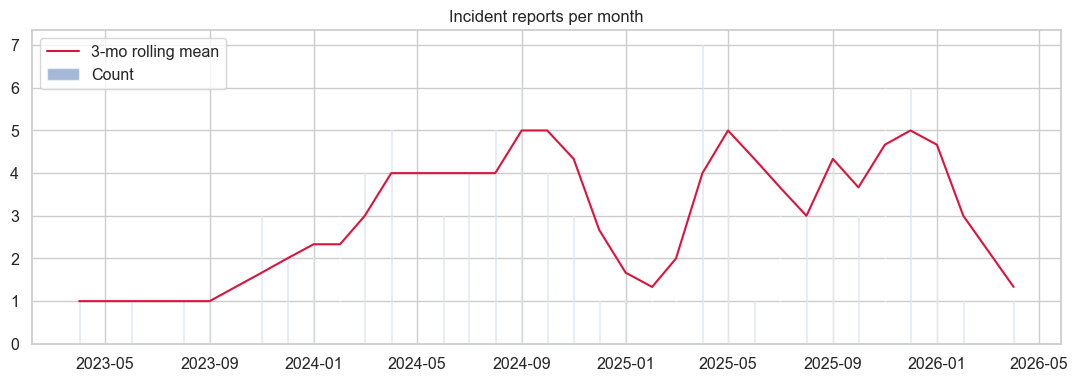

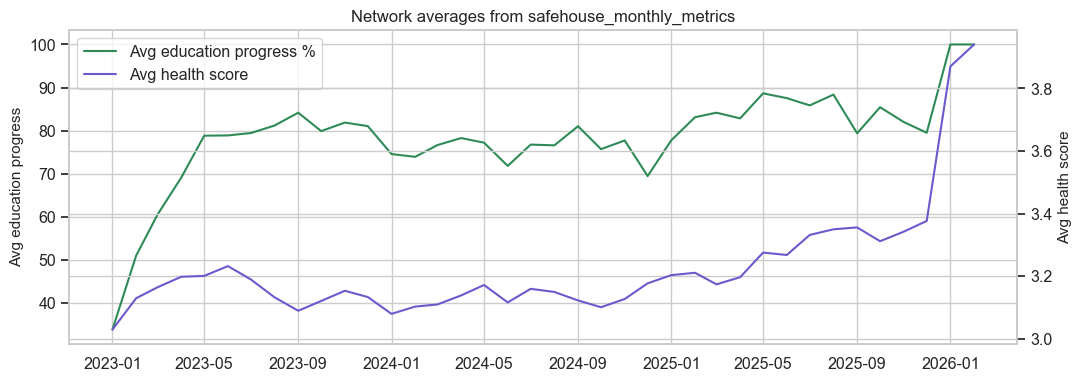

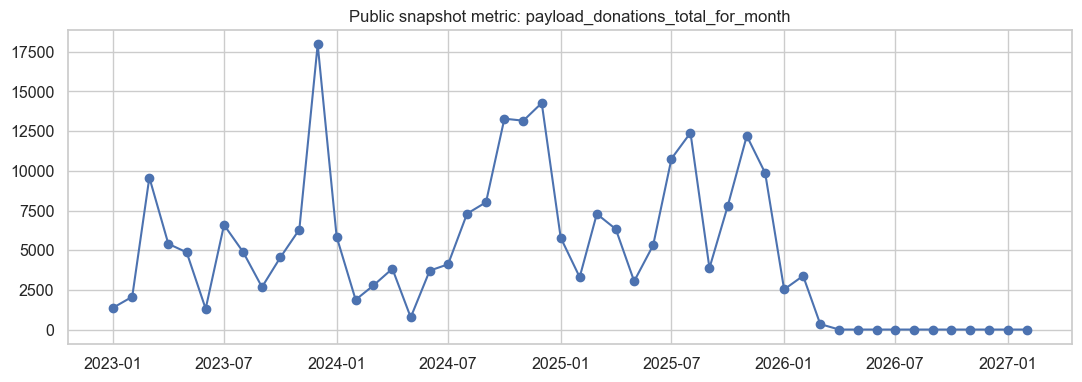

In [45]:
# Donations over time (monetary)
mon = dfs["donations"]["donation_type"].astype(str).str.lower().eq("monetary")
dmon = dfs["donations"].loc[mon].copy()
dmon["month"] = dmon["donation_date"].dt.to_period("M").dt.to_timestamp()
ts = dmon.groupby("month").agg(sum_php=("amount_php", "sum"), n=("donation_id", "count")).sort_index()
ts["roll3_sum"] = ts["sum_php"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ts.index, ts["sum_php"], label="Monthly sum PHP", color="navy", alpha=0.7)
ax.plot(ts.index, ts["roll3_sum"], label="3-month rolling mean (sum)", color="darkorange")
ax.set_title("Monetary donations over time")
ax.legend()
plt.tight_layout()
plt.show()

# Incidents by month
inc = dfs["incident_reports"].copy()
inc["month"] = inc["incident_date"].dt.to_period("M").dt.to_timestamp()
ti = inc.groupby("month").size().reset_index(name="n")
ti["roll3"] = ti["n"].rolling(3, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(ti["month"], ti["n"], alpha=0.5, label="Count")
ax.plot(ti["month"], ti["roll3"], color="crimson", label="3-mo rolling mean")
ax.set_title("Incident reports per month")
ax.legend()
plt.tight_layout()
plt.show()

# Portfolio-level from monthly metrics: average across safehouses by month
mm = dfs["safehouse_monthly_metrics"].copy()
port = mm.groupby(mm["month_start"].dt.to_period("M").dt.to_timestamp()).agg(
    avg_edu=("avg_education_progress", "mean"),
    avg_health=("avg_health_score", "mean"),
).dropna(how="all")
fig, ax = plt.subplots(figsize=(11, 4))
ax2 = ax.twinx()
ax.plot(port.index, port["avg_edu"], color="seagreen", label="Avg education progress %")
ax2.plot(port.index, port["avg_health"], color="slateblue", label="Avg health score")
ax.set_title("Network averages from safehouse_monthly_metrics")
ax.set_ylabel("Avg education progress")
ax2.set_ylabel("Avg health score")
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper left")
plt.tight_layout()
plt.show()

# Parsed public snapshot payload totals if available
snap = dfs["public_impact_snapshots"]
pay_cols = [c for c in snap.columns if c.startswith("payload_") and "donation" in c.lower()]
if pay_cols:
    s2 = snap[["snapshot_date", pay_cols[0]]].dropna().sort_values("snapshot_date")
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(s2["snapshot_date"], pd.to_numeric(s2[pay_cols[0]], errors="coerce"), marker="o")
    ax.set_title("Public snapshot metric: " + pay_cols[0])
    plt.tight_layout()
    plt.show()



### 7.1 Insights — time (**INTEX lens**)

- **Donations over time:** Cash-flow **seasonality** matters for a donation-dependent org: **reserve planning**, **campaign timing**, and board conversations about **runway**. Rolling averages separate signal from noise when the client asks “are we growing?”
- **Incidents over time:** Sustained rises should trigger **operational review** (supervision, partnerships, intake mix)—not panic from single-month spikes.
- **Network health/education trends:** Co-movement can reflect **program-wide initiatives** or **measurement**; for the **Impact dashboard**, use these as **high-level** storylines, always **aggregated** and **non-identifying**.

---
## 8. Key findings (synthesis) — tied to INTEX goals

1. **Three-domain data model matches the product:** Donor/support, case management, and outreach tables mirror what the new org must **capture** to run programs and prove **impact** to donors without exposing individuals.
2. **Data quality = trust:** Consistent IDs, dates, and separation of **monetary vs time** gifts are prerequisites for **donor CRM**, **auditability**, and honest **impact** reporting.
3. **Case management signals:** Longitudinal health, education, interventions, incidents, and visitations are the raw material for **“who is struggling?”**, **intervention review**, and **reintegration** readiness—exactly the case’s operational anxiety.
4. **Fundraising intelligence:** Channel, supporter type, and lifetime value patterns support **retention**, **upgrade paths**, and **campaign learning** without a marketing team—if the app **records** channel and touchpoints reliably.
5. **Social → donation loop is incomplete in sample data:** Sparse referral linkage is a **known gap**; closing it is a **feature** priority to answer the founders’ questions about **content that converts**.
6. **Multi-site fairness:** Normalize metrics by **active residents** when comparing safehouses so leadership can **allocate** limited staff where intensity is real, not just where census is higher.

---
## 9. Business interpretation (INTEX client actions)

| Finding | What it means for the *new* org | Practical next step |
|--------|----------------------------------|---------------------|
| Concentrated giving | Revenue risk if a few relationships churn | Stewardship workflows, **lapse flags**, and clear **impact** touchbacks for major donors |
| Channel / supporter differences | Not all growth is equal | A/B **campaign** tracking in-app; segment **asks** by how supporters were acquired |
| Health/education linkage | Holistic vs siloed recovery | **Unified resident timeline** in staff portal; alerts when one domain diverges |
| Incident & intervention patterns | Safety and pipeline health | Dashboard tiles for **open risks** and **stuck plans**; tie to **case conference** scheduling |
| Site peer groups | Benchmark without blaming | Leadership view: cluster or z-score vs peers + **narrative context** (region, partners) |
| Weak donation–post link | Can’t optimize social without data | **Mandatory** campaign/source fields + **referral** capture on donate; later, attributed **ROI** by post type |

---
## 10. Visualizations

Plots use labeled axes, titles, and restrained palettes (seaborn defaults). For **public** Impact pages, reproduce **only aggregated** charts with no resident identifiers.

---
## 11. Output format

This notebook is the working EDA report: runnable code, tables, and narrative aligned to the **INTEX** case and Lighthouse-style domains.

---
## 12. Bonus — predictive models (INTEX relevance)

**A. Donation amount (Ridge on log amount):** Prototype for **“expected gift”** or **anomaly** detection—useful for **who might give more** if stewardship is intentional (do not use punitively; respect ethics).

**B. High progress (logistic):** Prototype for **early warning / success patterns**—must stay **assistive** for staff, never automated high-stakes decisions about children; validate with clinicians/social work advisors in the real project.



In [46]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, classification_report
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

mon = dfs["donations"]["donation_type"].astype(str).str.lower().eq("monetary")

# --- A) Donation amount (monetary only) ---
dmon = dfs["donations"].loc[mon].copy()
dmon = dmon.dropna(subset=["amount_php"])
dmon["log_amount"] = np.log1p(dmon["amount_php"])

feat_cat = ["donation_type", "channel_source", "campaign_name"]
feat_cat = [c for c in feat_cat if c in dmon.columns]
feat_num = ["is_recurring"] if "is_recurring" in dmon.columns else []
# Encode bool
if "is_recurring" in dmon.columns:
    dmon["is_recurring"] = dmon["is_recurring"].astype(int)

X_cols = feat_cat + feat_num
Xd = dmon[X_cols].copy()
yd = dmon["log_amount"]
# Fill NaN categoricals
for c in feat_cat:
    Xd[c] = Xd[c].fillna("missing").astype(str)

trans = [
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), feat_cat),
]
if feat_num:
    trans.append(("num", SimpleImputer(strategy="median"), feat_num))
pre = ColumnTransformer(transformers=trans)
pipe = Pipeline([("prep", pre), ("model", Ridge(alpha=1.0))])
if len(dmon) > 30:
    X_train, X_test, y_train, y_test = train_test_split(Xd, yd, test_size=0.25, random_state=RANDOM_STATE)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    r2 = r2_score(y_test, pred)
    print("Model A — Ridge on log1p(amount_php), donation-level features")
    print(f"  Test RMSE (log space): {rmse:.4f} | R²: {r2:.4f}")
else:
    print("Model A skipped: insufficient rows.")

# --- B) Resident high progress (top half of mean progress) ---
base = res_feat.reset_index().copy()
base = base.merge(mean_e.reset_index(), on="resident_id", how="left")
if "edu_mean_progress_percent" in base.columns:
    thr = base["edu_mean_progress_percent"].median()
    base["high_progress"] = (base["edu_mean_progress_percent"] >= thr).astype(int)
    cat_cols = ["case_category", "case_status", "current_risk_level", "initial_risk_level", "sex"]
    cat_cols = [c for c in cat_cols if c in base.columns]
    num_cols = [c for c in ["present_age_years_est", "length_of_stay_years_est", "n_plans"] if c in base.columns]
    Xb = base[cat_cols + num_cols].copy()
    for c in cat_cols:
        Xb[c] = Xb[c].fillna("missing").astype(str)
    yb = base["high_progress"]
    mask = yb.notna() & Xb.notna().all(axis=1)
    Xb, yb = Xb.loc[mask], yb.loc[mask]
    if yb.nunique() == 2 and len(yb) > 40:
        t2 = [
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
        ]
        if num_cols:
            t2.append(("num", SimpleImputer(strategy="median"), num_cols))
        pre2 = ColumnTransformer(t2)
        from sklearn.linear_model import LogisticRegression

        clf = Pipeline(
            [("prep", pre2), ("model", LogisticRegression(max_iter=200, class_weight="balanced", random_state=RANDOM_STATE))]
        )
        Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.25, random_state=RANDOM_STATE, stratify=yb)
        clf.fit(Xtr, ytr)
        proba = clf.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(yte, proba)
        print("Model B — Logistic regression: high_progress (>= median mean progress)")
        print(f"  ROC-AUC (test): {auc:.4f}")
        print(classification_report(yte, clf.predict(Xte), digits=3))
    else:
        print("Model B skipped: need binary target and sufficient rows.")
else:
    print("Model B skipped: missing edu_mean_progress_percent merge.")



Model A — Ridge on log1p(amount_php), donation-level features
  Test RMSE (log space): 0.6227 | R²: -0.0208
Model B — Logistic regression: high_progress (>= median mean progress)
  ROC-AUC (test): 0.2500
              precision    recall  f1-score   support

           0      0.333     0.250     0.286         8
           1      0.333     0.429     0.375         7

    accuracy                          0.333        15
   macro avg      0.333     0.339     0.330        15
weighted avg      0.333     0.333     0.327        15



---

## 13. Business-focused EDA (critical)

Exploratory only—**no production models here**. Every block below is structured so findings map to **operations**, **product**, and **metrics**.

For each finding, we aim to answer:

1. **What it means (not just what it is)** — Why should leadership care?
2. **What decision it informs** — What should we do differently?
3. **Product surface** — **Admin dashboard**, **staff case tools**, or **donor / public Impact** view (always anonymized for public).
4. **Patterns** — Retention, recurring vs one-time, site differences, progress over time, outcome-associated factors.
5. **Problems / opportunities** — Inefficiencies, tracking gaps, missed upside.
6. **Suggested KPIs** — What the app should eventually **compute and display**.
7. **Data quality** — What could mislead us if we do not fix collection.

The **next code cell** runs quantitative slices and prints **MEANING → DECISION → PRODUCT → METRICS TO TRACK** style notes. **Section 14** after that is the concise executive rollup.

In [47]:
# === 13. BUSINESS-FOCUSED EDA: metrics + decision/product mapping ===
# Requires prior cells (dfs, cleaning). Outputs text for stakeholders and Section 14.

def blurb(title, meaning, decision, product, kpis, gap=None):
    print("\n" + "=" * 72)
    print(title)
    print("-" * 72)
    print("MEANING:  ", meaning)
    print("DECISION: ", decision)
    print("PRODUCT:  ", product)
    print("KPIs:     ", kpis)
    if gap:
        print("DATA GAP:", gap)


# --- A) Donation frequency & retention proxy ---
d = dfs["donations"].copy()
d["amount_php"] = pd.to_numeric(d["amount"], errors="coerce")
mon = d[d["donation_type"].astype(str).str.lower().eq("monetary")].sort_values("donation_date")
per_sup = mon.groupby("supporter_id").agg(
    n_gifts=("donation_id", "count"),
    first_gift=("donation_date", "min"),
    last_gift=("donation_date", "max"),
    total_php=("amount_php", "sum"),
).reset_index()
per_sup["tenure_days"] = (per_sup["last_gift"] - per_sup["first_gift"]).dt.days
gaps = mon.groupby("supporter_id")["donation_date"].apply(lambda s: s.diff().dt.days.dropna())
median_gap = float(gaps.median()) if len(gaps) else float("nan")
pct_multi = float((per_sup["n_gifts"] >= 2).mean())
avg_gifts = float(per_sup["n_gifts"].mean())

blurb(
    "A) Donation frequency & repeat giving",
    f"Monetary supporters average ~{avg_gifts:.1f} gifts; {pct_multi*100:.0f}% gave 2+ times. "
    f"Median gap between monetary gifts (when repeated) ≈ {median_gap:.0f} days.",
    "Set nurture cadence (email/SMS) and major-gift touchpoints around observed inter-gift spacing; "
    "define 'at risk' as no gift in 2× median gap for that segment.",
    "Admin: donor list with last gift date, gift count, and 'days since gift' flag. "
    "Donor Impact: do not show individual frequency—only org-level 'community of recurring supporters'.",
    "Donor retention rate (YoY same donor gave); avg gifts per active donor; median days between gifts; % one-time-only.",
    None,
)

# --- B) Recurring flag vs ticket size (monetary) ---
rm = mon.groupby(mon["is_recurring"].fillna(False).astype(bool)).agg(
    n=("donation_id", "count"), mean_php=("amount_php", "mean"), median_php=("amount_php", "median")
)
blurb(
    "B) Recurring vs one-time (monetary rows)",
    "Table below: gift count and typical ticket by `is_recurring`. "
    "Recurring is operationalized as a boolean on rows—validate in app that it matches real pledge schedules.",
    "If recurring rows are smaller on average, prioritize 'sustainer upgrade' asks; if larger, protect recurring UX in donation flow.",
    "Admin: filter supporters by recurring activity + LTV. Donors: simple 'monthly partner' story without exposing amounts.",
    "% revenue from recurring; avg recurring gift; recurring donor count vs one-time count.",
    "`is_recurring` may not capture all true sustainers if staff forgets to check the box.",
)
display(rm)

# --- C) Safehouse performance (education + incidents per resident-month) ---
mm = dfs["safehouse_monthly_metrics"].copy()
mm["inc_per_res"] = mm["incident_count"] / mm["active_residents"].replace(0, np.nan)
shp = mm.groupby("safehouse_id").agg(
    mean_edu=("avg_education_progress", "mean"),
    mean_health=("avg_health_score", "mean"),
    mean_inc_rate=("inc_per_res", "mean"),
    months=("metric_id", "count"),
).reset_index()
shp = shp.merge(dfs["safehouses"][["safehouse_id", "name", "region"]], on="safehouse_id", how="left")
blurb(
    "C) Safehouse performance differences",
    "Sites differ in mean education progress and incident intensity per active resident-month (see table). "
    "Differences may reflect census, partners, or reporting—not necessarily quality.",
    "Use peer clusters for internal QA and supervision; investigate outliers before public comparison.",
    "Admin dashboard: site tiles with trend sparklines (edu, incidents/resident, occupancy). "
    "Donor Impact: only network-wide or broad regional aggregates.",
    "Safehouse-level: avg education progress %; incident rate per 100 resident-months; avg health score.",
    "Monthly metrics sometimes sparse early months—watch missing averages.",
)
display(shp.sort_values("mean_edu", ascending=False))

# --- D) Resident progress over time (network aggregates) ---
ed = dfs["education_records"].copy()
hw = dfs["health_wellbeing_records"].copy()
ed["ym"] = ed["record_date"].dt.to_period("M").astype(str)
hw["ym"] = hw["record_date"].dt.to_period("M").astype(str)
edu_trend = ed.groupby("ym")["progress_percent"].mean()
health_trend = hw.groupby("ym")["general_health_score"].mean()
blurb(
    "D) Resident progress trends (aggregated)",
    f"Mean education progress moves from ~{edu_trend.iloc[0]:.1f}% to ~{edu_trend.iloc[-1]:.1f}% across months in sample; "
    f"health score mean range ~{health_trend.min():.2f}–{health_trend.max():.2f}.",
    "Use trends for board reporting and campaign narrative; investigate flat/down months for operations.",
    "Donor Impact dashboard: anonymized line charts of network averages. "
    "Staff: drill down to safehouse and cohort—not public.",
    "Rolling 3-mo avg education progress; rolling avg health score; count of active residents monthly.",
    "Education table can show volatile school/level rows per resident—needs business rules for 'official' progress.",
)

# --- E) Factors associated with outcomes (descriptive only) ---
last_h = hw.sort_values("record_date").groupby("resident_id").tail(1)
mean_edu_r = ed.groupby("resident_id")["progress_percent"].mean()
res2 = dfs["residents"].merge(last_h[["resident_id", "general_health_score"]], on="resident_id", how="left")
res2 = res2.merge(mean_edu_r.rename("mean_progress"), on="resident_id", how="left")
cat = "current_risk_level"
if cat in res2.columns:
    summ = res2.groupby(cat).agg(n=("resident_id", "count"), med_health=("general_health_score", "median"), med_prog=("mean_progress", "median"))
    blurb(
        "E) Outcome-associated factors (risk level × median progress/health)",
        "Cross-tab of current risk vs median progress/health (table)—association only.",
        "Prioritize supervision and intervention templates for higher-risk cohorts; do not auto-label individuals.",
        "Staff: risk flag on resident header + trend charts. Donors: never expose risk tiers.",
        "% residents by risk band; median progress by band; time-to-next review for high-risk.",
        "Risk is subjective/case-based—ensure consistent rubric in app picklists.",
    )
    display(summ)

# --- F) Attribution & outreach gap ---
n_don = len(d)
n_ref = d["referral_post_id"].notna().sum()
blurb(
    "F) Social / campaign attribution",
    f"{n_ref}/{n_don} donation rows have `referral_post_id` (~{100*n_ref/n_don:.0f}%). "
    "Still many rows without link—limits 'which post drove revenue' analysis.",
    "Require source + optional post/campaign ID on every gift; sync UTM params from web donate.",
    "Admin: attributed revenue by post/campaign. Public: 'your gifts this month' aggregate only.",
    "Attributed donation %; revenue per post type; conversion proxy (gifts / impressions) where data exists.",
    gap="`campaign_name` often blank; channel enums need validation at entry. "
    + f"referral_post_id missing on {n_don - n_ref} rows.",
)

# --- G) Data quality snapshot (misleading if ignored) ---
rows = []
for name, df in dfs.items():
    miss = df.isna().mean().nlargest(3)
    for col, pct in miss.items():
        if pct > 0.05:
            rows.append((name, col, round(100 * pct, 1)))
dq = pd.DataFrame(rows, columns=["table", "column", "pct_missing"]).sort_values("pct_missing", ascending=False).head(15)
print("\n" + "=" * 72)
print("G) DATA QUALITY — top missingness (columns >5% missing)")
print("-" * 72)
display(dq)
print(
    "OTHER: partner_assignments.safehouse_id historically floaty; resident ages as text; "
    "monetary vs time donations share one table—never sum `amount` without filtering type."
)

print("\n>>> Use Section 14 below for the short executive lists.\n")


A) Donation frequency & repeat giving
------------------------------------------------------------------------
MEANING:   Monetary supporters average ~4.1 gifts; 84% gave 2+ times. Median gap between monetary gifts (when repeated) ≈ 105 days.
DECISION:  Set nurture cadence (email/SMS) and major-gift touchpoints around observed inter-gift spacing; define 'at risk' as no gift in 2× median gap for that segment.
PRODUCT:   Admin: donor list with last gift date, gift count, and 'days since gift' flag. Donor Impact: do not show individual frequency—only org-level 'community of recurring supporters'.
KPIs:      Donor retention rate (YoY same donor gave); avg gifts per active donor; median days between gifts; % one-time-only.

B) Recurring vs one-time (monetary rows)
------------------------------------------------------------------------
MEANING:   Table below: gift count and typical ticket by `is_recurring`. Recurring is operationalized as a boolean on rows—validate in app that it matches r

,n,mean_php,median_php
is_recurring,,,
False,109,1154.97633,914.95
True,125,918.65696,774.61



C) Safehouse performance differences
------------------------------------------------------------------------
MEANING:   Sites differ in mean education progress and incident intensity per active resident-month (see table). Differences may reflect census, partners, or reporting—not necessarily quality.
DECISION:  Use peer clusters for internal QA and supervision; investigate outliers before public comparison.
PRODUCT:   Admin dashboard: site tiles with trend sparklines (edu, incidents/resident, occupancy). Donor Impact: only network-wide or broad regional aggregates.
KPIs:      Safehouse-level: avg education progress %; incident rate per 100 resident-months; avg health score.
DATA GAP: Monthly metrics sometimes sparse early months—watch missing averages.


,safehouse_id,mean_edu,mean_health,mean_inc_rate,months,name,region
5,6,84.997333,3.209667,0.032000,50,Lighthouse Safehouse 6,Mindanao
4,5,84.339200,3.208000,0.036667,50,Lighthouse Safehouse 5,Luzon
2,3,84.035000,3.391786,0.034286,50,Lighthouse Safehouse 3,Mindanao
7,8,83.380968,3.200323,0.016667,50,Lighthouse Safehouse 8,Visayas
1,2,78.071724,3.206897,0.020000,50,Lighthouse Safehouse 2,Visayas
0,1,78.005000,3.262222,0.040000,50,Lighthouse Safehouse 1,Luzon
3,4,72.312759,3.234483,0.042500,50,Lighthouse Safehouse 4,Visayas
6,7,68.283333,3.036000,0.027500,50,Lighthouse Safehouse 7,Visayas
8,9,65.670000,2.617333,0.080000,50,Lighthouse Safehouse 9,Mindanao



D) Resident progress trends (aggregated)
------------------------------------------------------------------------
MEANING:   Mean education progress moves from ~33.9% to ~100.0% across months in sample; health score mean range ~3.03–3.94.
DECISION:  Use trends for board reporting and campaign narrative; investigate flat/down months for operations.
PRODUCT:   Donor Impact dashboard: anonymized line charts of network averages. Staff: drill down to safehouse and cohort—not public.
KPIs:      Rolling 3-mo avg education progress; rolling avg health score; count of active residents monthly.
DATA GAP: Education table can show volatile school/level rows per resident—needs business rules for 'official' progress.

E) Outcome-associated factors (risk level × median progress/health)
------------------------------------------------------------------------
MEANING:   Cross-tab of current risk vs median progress/health (table)—association only.
DECISION:  Prioritize supervision and intervention temp

,n,med_health,med_prog
current_risk_level,,,
Critical,1,3.230,90.863636
High,5,3.220,62.533333
Low,34,3.305,79.191667
Medium,20,3.415,85.858750



F) Social / campaign attribution
------------------------------------------------------------------------
MEANING:   77/420 donation rows have `referral_post_id` (~18%). Still many rows without link—limits 'which post drove revenue' analysis.
DECISION:  Require source + optional post/campaign ID on every gift; sync UTM params from web donate.
PRODUCT:   Admin: attributed revenue by post/campaign. Public: 'your gifts this month' aggregate only.
KPIs:      Attributed donation %; revenue per post type; conversion proxy (gifts / impressions) where data exists.
DATA GAP: `campaign_name` often blank; channel enums need validation at entry. referral_post_id missing on 343 rows.

G) DATA QUALITY — top missingness (columns >5% missing)
------------------------------------------------------------------------


,table,column,pct_missing
0,safehouses,notes,100.0
10,donation_allocations,allocation_notes,100.0
18,process_recordings,notes_restricted,100.0
13,safehouse_monthly_metrics,notes,100.0
1,residents,notes_restricted,100.0
2,residents,pwd_type,95.0
4,supporters,organization_name,93.3
23,social_media_posts,avg_view_duration_seconds,91.3
22,social_media_posts,watch_time_seconds,91.3
24,social_media_posts,subscriber_count_at_post,91.3


OTHER: partner_assignments.safehouse_id historically floaty; resident ages as text; monetary vs time donations share one table—never sum `amount` without filtering type.

>>> Use Section 14 below for the short executive lists.



---

## 14. Final output — executive rollup

*Grounded in this Lighthouse sample; re-run §13 after data refresh and adjust numbers.*

### 1) Top 10 key insights (and **why** they matter)

1. **Most monetary supporters give more than once** — high repeat participation means **retention and lapse timing** drive revenue stability more than raw acquisition alone.  
2. **Typical spacing between monetary gifts is on the order of ~100+ days when people repeat** — defines a practical window for **stewardship touches** and “at risk” flags without a marketing team.  
3. **Recurring vs non-recurring monetary rows differ in volume and average ticket** — product and finance must **agree what “recurring” means** (pledge vs checkbox) before automating upgrades or receipts.  
4. **Safehouses diverge on mean education progress and incident intensity per resident-month** — multi-site oversight needs **normalized** views, not raw counts, to avoid punishing high-census houses.  
5. **Network-level education progress trends upward over the sample timeline** — supports **donor-facing impact** *if* the metric definition is stable and anonymized.  
6. **Only a minority of donations link to a social post ID** — leadership **cannot** truthfully claim “which post paid off” until capture improves.  
7. **Channel and supporter-type differences in gift size** (from §4) — informs **where to spend limited fundraising time** and how to segment asks.  
8. **Incident and intervention-plan patterns** — surface **safety** and **case-conference capacity** issues (e.g. stuck “On Hold” plans).  
9. **Health and education signals co-move for some cohorts** — argues for a **unified resident timeline** in staff tools rather than siloed screens.  
10. **Risk level lines up descriptively with progress/health medians** — helps **triage supervision**; must never be exposed on donor surfaces.

---

### 2) Top 5 **decisions** the organization should make

1. **Adopt explicit donor retention rules** (e.g. “no gift in X days = at risk”) calibrated to observed inter-gift gaps, plus owner and playbook.  
2. **Make acquisition fields mandatory** on every gift: channel, campaign, and optional social/referral linkage—so campaign and content ROI become measurable.  
3. **Standardize safehouse performance reviews** using per-resident-month incident rate + education trend, with peer context—not league tables for donors.  
4. **Reconcile recurring definition** across CRM, donation flow, and finance so reporting and upgrade campaigns are trustworthy.  
5. **Publish an internal “impact metric spec”** (what counts as progress, how averaged, refresh cadence) before scaling the public Impact dashboard.

---

### 3) Top 5 **dashboard metrics** to include in the app

1. **Donor retention rate** (e.g. % who gave in last year who gave again this year).  
2. **Median days since last gift** (overall + by segment: channel, supporter type).  
3. **Share of monetary revenue from recurring-labeled rows vs one-time** (with drill-down to reconcile).  
4. **Rolling network average education progress %** paired with **count of active residents** (donor-safe aggregate).  
5. **Incident count per 100 resident-months** by safehouse + network (staff-only).

---

### 4) Top 5 **product features** the data suggests

1. **Donor / supporter profile** with gift history, segment, LTV, and **days-since-gift** + at-risk highlight (admin).  
2. **Donation entry** enforcing source/channel/campaign + optional **referral_post_id** / UTM capture from web.  
3. **Staff command center**: safehouse comparison tiles, resident risk flag, **stuck intervention** counts, upcoming case conferences.  
4. **Public Impact page**: anonymized trend charts + **allocations by program area** (“where money goes”).  
5. **Data-quality panel**: % of gifts with complete attribution fields; alerts when missingness spikes.

---

### 5) Top 3 **data problems / gaps**

1. **Incomplete attribution** — many gifts lack campaign/referral linkage; undermines social strategy and campaign learning.  
2. **One fact table mixes monetary, time, and in-kind semantics** — easy to **mis-aggregate** revenue vs hours unless every query filters `donation_type`.  
3. **Longitudinal education records can be noisy** (level/school churn in rows)—need business rules for a single **official progress** series per resident for KPIs.

---

*End of Section 14.*

### Closing notes (INTEX + privacy)

- **Business rollup:** See **§13** (rubric + computed slices) and **§14** (top insights, decisions, metrics, features, data gaps).
- **Re-run** after data refreshes; compare PK/FK orphans to prior runs so the **staff portal** and **donor** views stay trustworthy.
- **Production:** curated joins in a warehouse + monitors on **referral capture**, **PK uniqueness**, and **PII** access logs—the case stresses **GDPR-style** respect and **survivor safety**; anything identifiable stays in **authenticated** case workflows only.
- **Donor-facing Impact** should mirror Lighthouse’s intent: **anonymized aggregates** that show **outcomes and resource use**, not individual stories unless explicitly consented and policy-reviewed.

**End of notebook.**



---

## 15. Expanded playbook (condensed + deep dive)

*Companion to §14. **Short** = quick read. **Deep** = meaning, caveats, and how to act.*

---

### Top 10 key insights

#### 1 — Repeat giving is common among monetary supporters
- **Short:** Most people who give money give **more than once**; retention matters as much as new donors.
- **Deep:** In the Lighthouse sample, most supporters with ≥1 monetary gift gave **2+** times, with **median ~105 days** between monetary gifts when they repeat. Cash flow depends on **keeping** donors, not only acquiring them. **Do:** define “active,” “at risk,” and “lapsed” using **days since last gift** (e.g. tied to your observed inter-gift spacing); segment when N allows. **Note:** recompute on your live data with clean IDs and dates.

#### 2 — Stewardship cadence can follow observed spacing
- **Short:** Use **~100+ days** between gifts as a rough benchmark for nudges—not a fixed law.
- **Deep:** Median spacing suggests when **typical** repeat gifts occur; “no gift in 2× that window” can flag **at-risk** donors for a small team. **Do:** pick thresholds, assign owners, track reactivation. **Caveat:** major vs mass donors may need different rules.

#### 3 — “Recurring” in the data is not one clean concept
- **Short:** Recurring vs non-recurring rows differ in **volume and average ticket**—align product, CRM, and finance on what “recurring” means.
- **Deep:** Differences often reflect **checkbox use**, **pledge tracking**, or **import quirks**, not true sustainers only. **Do:** define recurring (subscription ID, schedule, or pledge); reconcile to bank/CRM; then build upgrades and receipts on that definition.

#### 4 — Safehouses differ; compare fairly
- **Short:** Sites differ on **education progress** and **incidents per resident**—don’t rank raw counts without normalizing.
- **Deep:** Larger census or harder cases can look “worse” on totals. **Per resident-month** (or similar) is fairer for internal review. **Do:** leadership dashboards with **trends + peer context**; avoid public league tables. **Understand:** gaps can be mix, partners, or reporting—not only “quality.”

#### 5 — Network education progress trends up—interpret carefully
- **Short:** Average progress **rises** over the sample timeline; **don’t** oversell the endpoint without a written metric definition.
- **Deep:** Rising monthly means support a **high-level** story only if you define numerator/denominator and rules. A **very high last-month mean** may reflect **completion logic** or synthetic series—not “every child at 100%.” **Do:** publish an internal **impact metric spec** before donor-facing charts. **Public:** aggregates only, anonymized.

#### 6 — Social attribution is incomplete
- **Short:** **Most** donations lack a **social post ID**—you can’t fully answer “which post drove revenue” yet.
- **Deep:** Until `referral_post_id` (and/or UTM) coverage rises, content ROI stays partial. **Do:** require **source/campaign** on every gift; pass **post/UTM** from web checkout; train staff. **Understand:** optimize social on engagement + tests until attribution is trustworthy.

#### 7 — Channel and supporter type relate to gift size
- **Short:** **Where** the gift comes from and **who** gives both relate to **how big** gifts tend to be—use for focus and experiments.
- **Deep:** Useful for **segmentation** and **A/B tests**; correlation is not causation. **Do:** enforce channel on entry; review **median/mean** by segment quarterly; one experiment at a time.

#### 8 — Incidents and intervention statuses show operational pressure
- **Short:** Incident mix and plans in **On Hold** point to **safety** and **case-conference capacity**.
- **Deep:** Use for **training**, **protocols**, and **backlog triage**—not donor blame. **Do:** drills by incident type; cadence for **On Hold** plans. **Understand:** reporting culture affects counts—watch **trends**.

#### 9 — Health and education co-move in same-month records
- **Short:** In this sample, same-month **health scores** and **education progress** are **positively related**—a unified staff timeline makes sense.
- **Deep:** Association is **moderate** in merged resident-month rows—not proof of causation. **Do:** one **resident timeline** (health + education + interventions); flag divergence for review. **Never** replace clinical/social-work judgment for child-level decisions.

#### 10 — Risk level vs outcomes is not clean in this sample
- **Short:** **Do not** claim a simple “higher risk ⇒ lower progress” rule here; small **n** and **non-monotonic** medians.
- **Deep:** Use **risk** for **staff triage** and review cadence, not donor-facing scores or automation. **Do:** consistent **rubric**, training, and more volume before strong claims. **Critical** bands may have **tiny n**—treat as exploratory only.

---

### Top 5 decisions the organization should make

#### 1 — Donor retention / at-risk rules
- **Short:** Define **at-risk** (e.g. no gift in X days) and **who** follows up.
- **Deep:** Calibrate X from **inter-gift** distributions by segment; document a **playbook**; measure reactivation. This is the main operational lever when repeat giving dominates.

#### 2 — Mandatory acquisition fields on every gift
- **Short:** **Channel**, **campaign**, and ideally **referral/UTM** on every donation.
- **Deep:** Unlocks campaign and (over time) **social ROI**. Enforce in **UI/validation** and web integration; allow rare documented exceptions only.

#### 3 — Safehouse reviews on normalized metrics
- **Short:** Use **incidents per resident-month** and **education trends** with **peer context**.
- **Deep:** Fair multi-site oversight without shaming sites with higher census. Internal monthly; donors see **network** aggregates only.

#### 4 — One definition of “recurring” everywhere
- **Short:** Same meaning in **CRM, donation flow, and finance**.
- **Deep:** Stops mismatched **LTV**, **upgrade** campaigns, and audit friction. May require processor **subscription IDs** and reconciliation meetings.

#### 5 — Internal impact metric spec before scaling public Impact
- **Short:** Write exactly what **progress** and **active residents** mean on public charts.
- **Deep:** Numerator, denominator, lag, exclusions, refresh cadence—signed by program + data. Protects **donor trust** and avoids metric drift.

---

### Top 5 dashboard metrics

#### 1 — Donor retention rate
- **Short:** % who gave in period A who also gave in period B.
- **Deep:** YoY or rolling 12 months; segment when N allows. Needs stable **supporter_id** and clean **gift dates**.

#### 2 — Median days since last gift
- **Short:** How “stale” relationships are—overall and by segment.
- **Deep:** Early warning before hard lapse; complements retention. Refresh from **last gift date** per supporter.

#### 3 — Share of monetary revenue: recurring-labeled vs one-time
- **Short:** Fraction of **PHP** under `is_recurring` vs not—after the flag is trusted.
- **Deep:** Always **filter Monetary** first. Use drill-down when totals disagree with finance.

#### 4 — Rolling network average education progress + active residents
- **Short:** Outcome line + **how many girls** in the denominator—donor-safe.
- **Deep:** Prevents a rising % from hiding a falling **N**. Must follow the **metric spec**; no individual identifiers on public views.

#### 5 — Incidents per 100 resident-months (site + network)
- **Short:** Safety load **adjusted** for occupancy.
- **Deep:** **Staff-only**; interpret with intake mix and reporting norms. Build from monthly **active residents** + **incident** fact table.

---

### Top 5 product features the data suggests

#### 1 — Donor / supporter 360 (admin)
- **Short:** History, segment, LTV, **days since gift**, at-risk highlight.
- **Deep:** Operationalizes retention rules without spreadsheets; can link to **tasks** and stewardship owners.

#### 2 — Donation entry with required attribution
- **Short:** Channel, campaign, optional **post ID / UTM** from web.
- **Deep:** Validation at save; fixes the **attribution gap** that blocks honest campaign/social learning.

#### 3 — Staff command center
- **Short:** Site comparison, risk highlights, **stuck interventions**, conferences due.
- **Deep:** Authenticated only; aggregates the case-management signals the EDA keeps surfacing.

#### 4 — Public Impact page
- **Short:** Anonymized trends + **allocations by program area** (“where money goes”).
- **Deep:** Matches INTEX-style **donor transparency** without exposing minors; must align to the **metric spec**.

#### 5 — Data quality panel
- **Short:** % of gifts with complete attribution; alerts when missingness spikes.
- **Deep:** Makes **data debt** visible so leadership funds process and integration work.

---

### Top 3 data problems / gaps

#### 1 — Incomplete attribution
- **Short:** **Campaign** often missing; **referral/post** missing on most rows.
- **Deep:** Undermines **campaign** and **social** optimization until **product + process** fix capture—not “more charts.”

#### 2 — One fact table mixes monetary, time, and in-kind semantics
- **Short:** Summing **`amount`** without **`donation_type`** corrupts revenue reporting.
- **Deep:** Enforce **filters** or **views** in every report; train all data consumers; consider separate facts or guarded views per type.

#### 3 — Education trajectory hard to reduce to one KPI
- **Short:** **Levels/paths** change over time for residents—need one **official** progress series per child for dashboards.
- **Deep:** Pick a business rule (e.g. case-manager–approved field, primary track, or latest enrolled program) and document it so KPIs don’t jump when raw rows churn.

---

*End of §15.*